# 📊 Data Preparation — Home Credit

Objectif : préparer et analyser les données principales (`application_train`) pour construire un modèle de scoring crédit.

Dans cette étape :
- exploration des données
- analyse de la cible
- identification des variables importantes
- étude des valeurs manquantes

Cette phase est essentielle pour garantir la qualité du modèle en aval.

Etape 1 : Préparez, nettoyez et enrichissez vos données 

Vous allez découvrir et préparer les données nécessaires à la construction de votre modèle de scoring. Cela inclut le nettoyage, la fusion des différentes sources, l'encodage des variables et la création de nouvelles features pertinentes. L'objectif est de constituer un dataset propre et enrichi, prêt pour l'entraînement. Vous devrez aussi analyser la qualité de vos variables et les déséquilibres dans les classes.

 

Prérequis

Avoir exploré les données brutes fournies.

Avoir vérifié les formats et les valeurs manquantes.

Avoir identifié les colonnes clés pour les jointures.

Avoir pris en compte les enjeux métiers (par ex. déséquilibre des classes).

Résultat attendu

 Un jeu de données propre, fusionné et enrichi, prêt à être utilisé pour l'entraînement.

Recommandations

 

Charger chaque fichier séparément et inspecter ses colonnes.

Utiliser Pandas pour fusionner les jeux de données.

Visualiser la distribution des classes cibles.

Créer de nouvelles features à partir des variables existantes si nécessaire.

Éviter de supprimer trop rapidement les colonnes avec des valeurs manquantes : explorer les possibilités d’imputation.

 

Points de vigilance

Oublier de vérifier les doublons.

Supprimer des colonnes sans analyser leur importance métier.

Imputer sans documenter ni justifier.

Fusionner sans gérer les duplications ou pertes de lignes.

Encoder sans faire attention au type de modèle prévu (ordinal vs. nominal).


Outils

Pandas

Matplotlib et Seaborn pour la visualisation

Scikit-learn pour le preprocessing

Missingno pour visualiser les valeurs manquantes

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
PROJECT_DIR = Path.cwd().resolve().parent
DATA_DIR = PROJECT_DIR / "data" / "raw"

print("PROJECT_DIR =", PROJECT_DIR)
print("DATA_DIR =", DATA_DIR)
print("DATA_DIR exists ?", DATA_DIR.exists())

PROJECT_DIR = C:\Users\bapti\Documents\home_credit_mlops
DATA_DIR = C:\Users\bapti\Documents\home_credit_mlops\data\raw
DATA_DIR exists ? True


In [3]:
csv_files = sorted([p.name for p in DATA_DIR.glob("*.csv")])
csv_files

['HomeCredit_columns_description.csv',
 'POS_CASH_balance.csv',
 'application_test.csv',
 'application_train.csv',
 'bureau.csv',
 'bureau_balance.csv',
 'credit_card_balance.csv',
 'installments_payments.csv',
 'previous_application.csv',
 'sample_submission.csv']

## 📥 Chargement des données

Les données sont chargées depuis le dossier `data/raw`.

Les deux tables principales :
- `application_train` : contient la cible (`TARGET`)
- `application_test` : sans cible (pour la prédiction finale)

On vérifie les dimensions pour s'assurer de la cohérence des fichiers.

In [4]:
app_train = pd.read_csv(DATA_DIR / "application_train.csv")
app_test = pd.read_csv(DATA_DIR / "application_test.csv")

print("application_train shape:", app_train.shape)
print("application_test shape:", app_test.shape)

application_train shape: (307511, 122)
application_test shape: (48744, 121)


In [5]:
app_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## 🔍 Aperçu des données

On affiche les premières lignes pour comprendre la structure :
- identifiant client (`SK_ID_CURR`)
- variables socio-économiques
- informations de crédit

Cela permet de valider que les données sont correctement chargées.

Vérification des types de variables

In [6]:
types_df = pd.DataFrame({
    "column": app_train.columns,
    "dtype": app_train.dtypes.astype(str),
    "n_unique": app_train.nunique(),
    "missing_ratio": app_train.isna().mean()
}).sort_values("n_unique")

types_df.head(30)

,column,dtype,n_unique,missing_ratio
TARGET,TARGET,int64,2,0.0
NAME_CONTRACT_TYPE,NAME_CONTRACT_TYPE,object,2,0.0
FLAG_OWN_REALTY,FLAG_OWN_REALTY,object,2,0.0
FLAG_OWN_CAR,FLAG_OWN_CAR,object,2,0.0
FLAG_WORK_PHONE,FLAG_WORK_PHONE,int64,2,0.0
FLAG_CONT_MOBILE,FLAG_CONT_MOBILE,int64,2,0.0
FLAG_EMP_PHONE,FLAG_EMP_PHONE,int64,2,0.0
FLAG_MOBIL,FLAG_MOBIL,int64,2,0.0
FLAG_PHONE,FLAG_PHONE,int64,2,0.0
FLAG_EMAIL,FLAG_EMAIL,int64,2,0.0


In [7]:
potential_categorical_num = types_df[
    (types_df["dtype"].isin(["int64", "float64"])) &
    (types_df["n_unique"] <= 10) &
    (types_df["column"] != "TARGET")
]

potential_categorical_num

,column,dtype,n_unique,missing_ratio
FLAG_WORK_PHONE,FLAG_WORK_PHONE,int64,2,0.000000
FLAG_CONT_MOBILE,FLAG_CONT_MOBILE,int64,2,0.000000
FLAG_EMP_PHONE,FLAG_EMP_PHONE,int64,2,0.000000
FLAG_MOBIL,FLAG_MOBIL,int64,2,0.000000
FLAG_PHONE,FLAG_PHONE,int64,2,0.000000
FLAG_EMAIL,FLAG_EMAIL,int64,2,0.000000
LIVE_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,int64,2,0.000000
REG_CITY_NOT_WORK_CITY,REG_CITY_NOT_WORK_CITY,int64,2,0.000000
LIVE_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,int64,2,0.000000
REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_LIVE_CITY,int64,2,0.000000


## Analyse des types de variables

Les types pandas ne suffisent pas à distinguer les variables numériques continues des variables catégorielles encodées numériquement.

Certaines variables avec peu de modalités, même si elles sont stockées en `int` ou `float`, peuvent représenter des catégories. Elles sont donc identifiées séparément avant l’encodage et la modélisation.

In [8]:
print("Nombre de colonnes :", len(app_train.columns))
print("\nPremières colonnes :")
print(app_train.columns.tolist()[:30])

print("\nTypes :")
print(app_train.dtypes.head(30))

Nombre de colonnes : 122

Premières colonnes :
['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS']

Types :
SK_ID_CURR                      int64
TARGET                          int64
NAME_CONTRACT_TYPE             object
CODE_GENDER                    object
FLAG_OWN_CAR                   object
FLAG_OWN_REALTY                object
CNT_CHILDREN                    int64
AMT_INCOME_TOTAL              float64
AMT_CREDIT                    float64
AMT_ANNUITY                   float64
AMT_GOODS_PRICE          

## 🎯 Analyse de la variable cible

La variable `TARGET` indique :
- 0 : client solvable
- 1 : défaut de paiement

On observe un fort déséquilibre des classes (~8% de défauts).
👉 Cela aura un impact important sur :
- le choix des métriques
- la stratégie de modélisation

In [9]:
print("Distribution TARGET (effectifs) :")
print(app_train["TARGET"].value_counts(dropna=False))

print("\nDistribution TARGET (proportions) :")
print(app_train["TARGET"].value_counts(normalize=True, dropna=False))

Distribution TARGET (effectifs) :
TARGET
0    282686
1     24825
Name: count, dtype: int64

Distribution TARGET (proportions) :
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


In [10]:
target_dist = app_train["TARGET"].value_counts(normalize=True).rename("ratio")
target_count = app_train["TARGET"].value_counts().rename("count")

target_summary = pd.concat([target_count, target_dist], axis=1)
target_summary

,count,ratio
TARGET,,
0,282686,0.919271
1,24825,0.080729


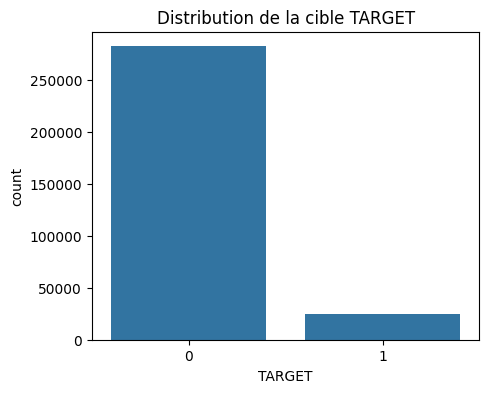

In [11]:
plt.figure(figsize=(5,4))
sns.countplot(x="TARGET", data=app_train)
plt.title("Distribution de la cible TARGET")
plt.show()

## Distribution de la cible

La variable cible est fortement déséquilibrée : la classe 0 représente les clients sans défaut, tandis que la classe 1 représente les clients en défaut.

Ce déséquilibre devra être pris en compte pendant la modélisation avec une validation stratifiée et une gestion du poids des classes.

In [12]:
print("Doublons SK_ID_CURR dans app_train :", app_train["SK_ID_CURR"].duplicated().sum())
print("Doublons SK_ID_CURR dans app_test  :", app_test["SK_ID_CURR"].duplicated().sum())

Doublons SK_ID_CURR dans app_train : 0
Doublons SK_ID_CURR dans app_test  : 0


In [13]:
duplicates_train = app_train.duplicated().sum()
duplicates_test = app_test.duplicated().sum()

print("Doublons train :", duplicates_train)
print("Doublons test :", duplicates_test)

Doublons train : 0
Doublons test : 0


## Vérification des doublons

Les doublons sont vérifiés afin d’éviter de biaiser l’apprentissage du modèle.  
Aucun doublon complet ne doit être conservé sans justification.

## ⚠️ Analyse des valeurs manquantes

Certaines variables présentent un fort taux de valeurs manquantes (>50%).

👉 Important :
- ces variables ne sont pas supprimées immédiatement
- certaines peuvent être très informatives (ex : EXT_SOURCE)

👉 Une stratégie d’imputation ou de sélection sera définie plus tard.

In [14]:
missing_ratio = (
    app_train.isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_ratio")
)

missing_count = (
    app_train.isna()
    .sum()
    .rename("missing_count")
)

missing_df = pd.concat([missing_count, missing_ratio], axis=1)
missing_df.head(20)

,missing_count,missing_ratio
SK_ID_CURR,0,0.000000
TARGET,0,0.000000
NAME_CONTRACT_TYPE,0,0.000000
CODE_GENDER,0,0.000000
FLAG_OWN_CAR,0,0.000000
FLAG_OWN_REALTY,0,0.000000
CNT_CHILDREN,0,0.000000
AMT_INCOME_TOTAL,0,0.000000
AMT_CREDIT,0,0.000000
AMT_ANNUITY,12,0.000039


In [15]:
missing_df[missing_df["missing_ratio"] > 0.5].head(50)

,missing_count,missing_ratio
OWN_CAR_AGE,202929,0.659908
EXT_SOURCE_1,173378,0.563811
APARTMENTS_AVG,156061,0.507497
BASEMENTAREA_AVG,179943,0.585160
YEARS_BUILD_AVG,204488,0.664978
COMMONAREA_AVG,214865,0.698723
ELEVATORS_AVG,163891,0.532960
ENTRANCES_AVG,154828,0.503488
FLOORSMIN_AVG,208642,0.678486
LANDAREA_AVG,182590,0.593767


In [16]:
import missingno as msno

missing_df = pd.DataFrame({
    "missing_count": app_train.isna().sum(),
    "missing_ratio": app_train.isna().mean()
}).sort_values("missing_ratio", ascending=False)

missing_df.head(20)

,missing_count,missing_ratio
COMMONAREA_AVG,214865,0.698723
COMMONAREA_MODE,214865,0.698723
COMMONAREA_MEDI,214865,0.698723
NONLIVINGAPARTMENTS_MEDI,213514,0.694330
NONLIVINGAPARTMENTS_MODE,213514,0.694330
NONLIVINGAPARTMENTS_AVG,213514,0.694330
FONDKAPREMONT_MODE,210295,0.683862
LIVINGAPARTMENTS_AVG,210199,0.683550
LIVINGAPARTMENTS_MEDI,210199,0.683550
LIVINGAPARTMENTS_MODE,210199,0.683550


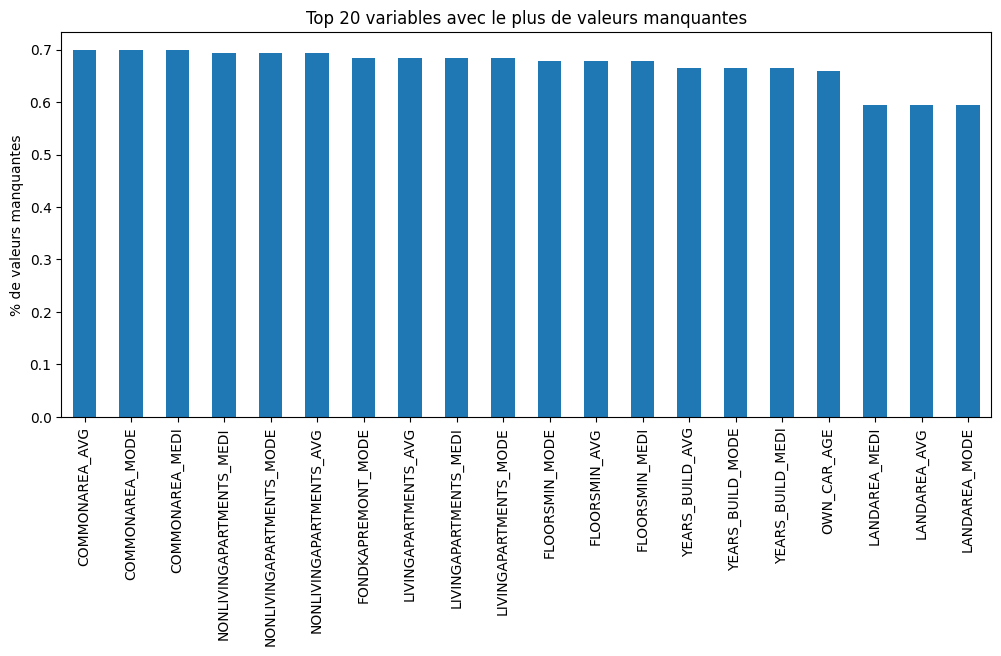

In [17]:
missing_ratio = app_train.isnull().mean().sort_values(ascending=False)

missing_ratio.head(20).plot(kind='bar', figsize=(12,5))
plt.title("Top 20 variables avec le plus de valeurs manquantes")
plt.ylabel("% de valeurs manquantes")
plt.show()

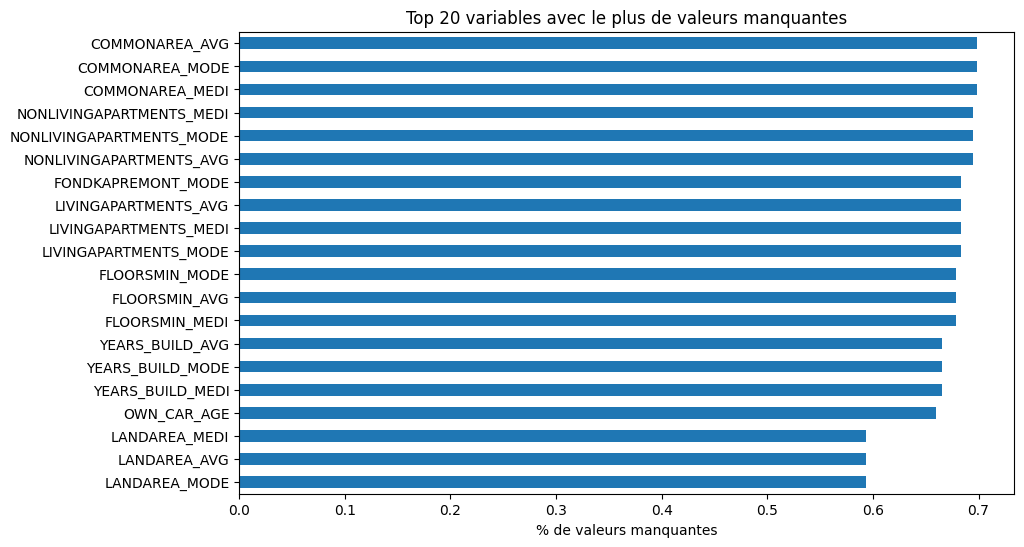

In [18]:
missing = app_train.isnull().mean().sort_values(ascending=False)

missing_top = missing.head(20)

plt.figure(figsize=(10,6))
missing_top.plot(kind="barh")
plt.title("Top 20 variables avec le plus de valeurs manquantes")
plt.xlabel("% de valeurs manquantes")
plt.gca().invert_yaxis()
plt.show()

## Analyse des valeurs manquantes

Les valeurs manquantes sont analysées avant toute suppression ou imputation.  
Elles peuvent porter une information métier importante dans un contexte de scoring crédit.

L’objectif n’est donc pas de supprimer automatiquement les colonnes incomplètes, mais d’identifier les variables réellement exploitables.

## 🧱 Types de variables

Le dataset contient :
- variables numériques (majoritaires)
- variables catégorielles

👉 La majorité des modèles ML pourront être utilisés directement après encodage des variables catégorielles.

In [19]:
print(app_train.dtypes.value_counts())

float64    65
int64      41
object     16
Name: count, dtype: int64


In [20]:
cat_cols = app_train.select_dtypes(include=["object"]).columns.tolist()
num_cols = app_train.select_dtypes(exclude=["object"]).columns.tolist()

print("Nb colonnes catégorielles :", len(cat_cols))
print("Nb colonnes numériques    :", len(num_cols))

print("\nExemples de colonnes catégorielles :")
print(cat_cols[:20])

Nb colonnes catégorielles : 16
Nb colonnes numériques    : 106

Exemples de colonnes catégorielles :
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


## Types de variables

Une première séparation est réalisée selon les types pandas (`object` vs numérique).

👉 Attention : certaines colonnes stockées sous forme numérique peuvent en réalité correspondre à :

* des variables binaires
* des catégories codées
* des identifiants

Cette distinction technique est donc une première lecture, à compléter par une analyse métier des variables.


In [21]:
# Variables numériques avec peu de modalités -> potentiellement catégorielles/binaire
low_card_num_cols = [
    col for col in app_train.select_dtypes(exclude=["object"]).columns
    if app_train[col].nunique() <= 10
]

print("Variables numériques à faible cardinalité (à examiner) :")
print(low_card_num_cols[:30])
print("Nb :", len(low_card_num_cols))

Variables numériques à faible cardinalité (à examiner) :
['TARGET', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'DEF_30_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14']
Nb : 40


1. Distribution de la cible

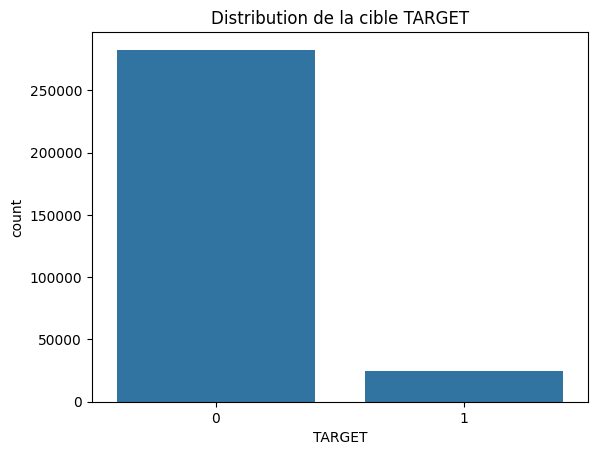

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="TARGET", data=app_train)
plt.title("Distribution de la cible TARGET")
plt.show()

2. Variables numériques importantes

## Variables financières clés

Trois variables financières ont été étudiées en priorité :

* `AMT_INCOME_TOTAL` : niveau de revenu du client
* `AMT_CREDIT` : montant du crédit demandé
* `AMT_ANNUITY` : charge de remboursement

👉 Ce choix est justifié à la fois :

* par la logique métier du crédit scoring
* par leur rôle dans la construction de ratios d’endettement et de solvabilité
* par leur potentiel explicatif sur le risque de défaut


In [23]:
important_num_cols = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY"
]

app_train[important_num_cols].describe()

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY
count,3.075110e+05,3.075110e+05,307499.000000
mean,1.687979e+05,5.990260e+05,27108.573909
std,2.371231e+05,4.024908e+05,14493.737315
min,2.565000e+04,4.500000e+04,1615.500000
25%,1.125000e+05,2.700000e+05,16524.000000
50%,1.471500e+05,5.135310e+05,24903.000000
75%,2.025000e+05,8.086500e+05,34596.000000
max,1.170000e+08,4.050000e+06,258025.500000


## 🔗 Corrélation avec la cible

On analyse les variables les plus corrélées avec `TARGET`.

Observations :
- `EXT_SOURCE_1/2/3` sont fortement corrélées négativement → variables clés
- certaines variables liées au crédit ou au profil client ressortent

👉 Ces variables seront importantes pour la modélisation.

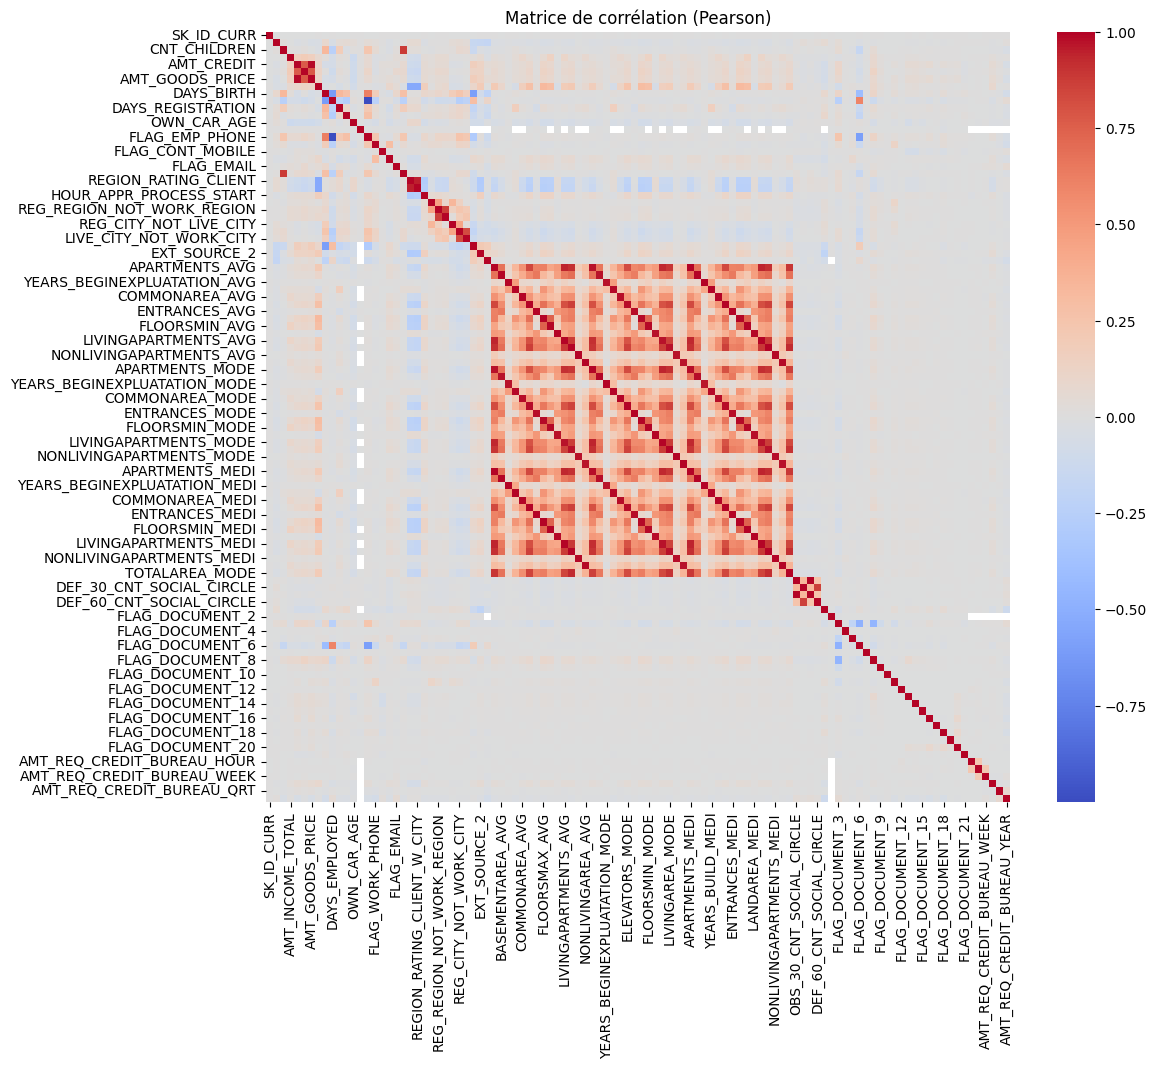

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# Corrélation
corr_matrix = app_train.corr(numeric_only=True)

# Plot
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Matrice de corrélation (Pearson)")
plt.show()

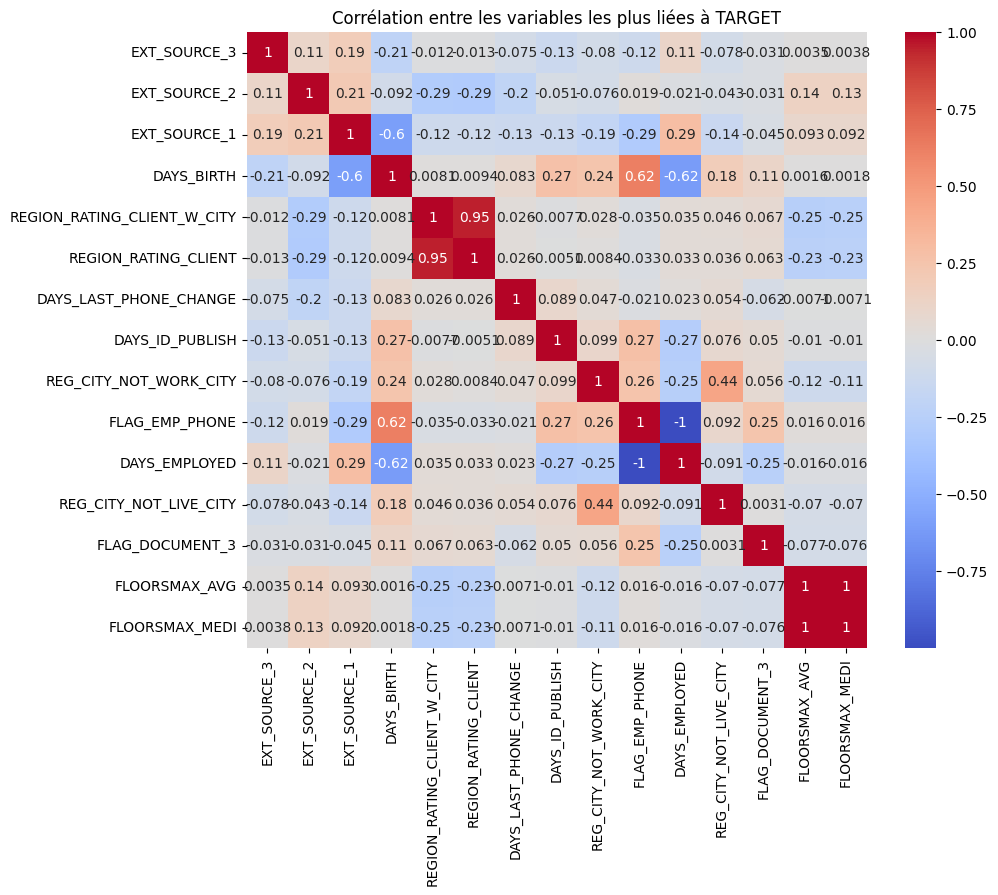

In [25]:
# Corrélation avec TARGET
corr_target = app_train.corr(numeric_only=True)["TARGET"].drop("TARGET")

# Sélection des variables les plus corrélées
top_features = corr_target.abs().sort_values(ascending=False).head(15).index

# Matrice réduite
corr_subset = app_train[top_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_subset, annot=True, cmap="coolwarm", center=0)
plt.title("Corrélation entre les variables les plus liées à TARGET")
plt.show()

## Matrice de corrélation

Une matrice de corrélation de Pearson est calculée sur les variables numériques afin d’identifier les relations linéaires entre variables.

👉 Une première matrice globale permet d’avoir une vision d’ensemble, mais elle est difficile à interpréter en raison du grand nombre de variables.

👉 Une seconde matrice est donc réalisée en se concentrant sur les variables les plus corrélées à la cible `TARGET`, ce qui permet une analyse plus lisible et pertinente.


In [26]:
corr = app_train.corr(numeric_only=True)["TARGET"].sort_values()

print("Plus corrélées négativement :")
print(corr.head(10))

print("\nPlus corrélées positivement :")
print(corr.tail(10))

Plus corrélées négativement :
EXT_SOURCE_3                 -0.178919
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_1                 -0.155317
DAYS_EMPLOYED                -0.044932
FLOORSMAX_AVG                -0.044003
FLOORSMAX_MEDI               -0.043768
FLOORSMAX_MODE               -0.043226
AMT_GOODS_PRICE              -0.039645
REGION_POPULATION_RELATIVE   -0.037227
ELEVATORS_AVG                -0.034199
Name: TARGET, dtype: float64

Plus corrélées positivement :
FLAG_DOCUMENT_3                0.044346
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_WORK_CITY         0.050994
DAYS_ID_PUBLISH                0.051457
DAYS_LAST_PHONE_CHANGE         0.055218
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
DAYS_BIRTH                     0.078239
TARGET                         1.000000
Name: TARGET, dtype: float64


In [27]:
corr_target = app_train.corr(numeric_only=True)["TARGET"].drop("TARGET").sort_values()

top_neg = corr_target.head(5)
top_pos = corr_target.tail(5)

print("Top 5 corrélations négatives avec TARGET :")
print(top_neg)
print()
print("Top 5 corrélations positives avec TARGET :")
print(top_pos)

Top 5 corrélations négatives avec TARGET :
EXT_SOURCE_3    -0.178919
EXT_SOURCE_2    -0.160472
EXT_SOURCE_1    -0.155317
DAYS_EMPLOYED   -0.044932
FLOORSMAX_AVG   -0.044003
Name: TARGET, dtype: float64

Top 5 corrélations positives avec TARGET :
DAYS_ID_PUBLISH                0.051457
DAYS_LAST_PHONE_CHANGE         0.055218
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
DAYS_BIRTH                     0.078239
Name: TARGET, dtype: float64


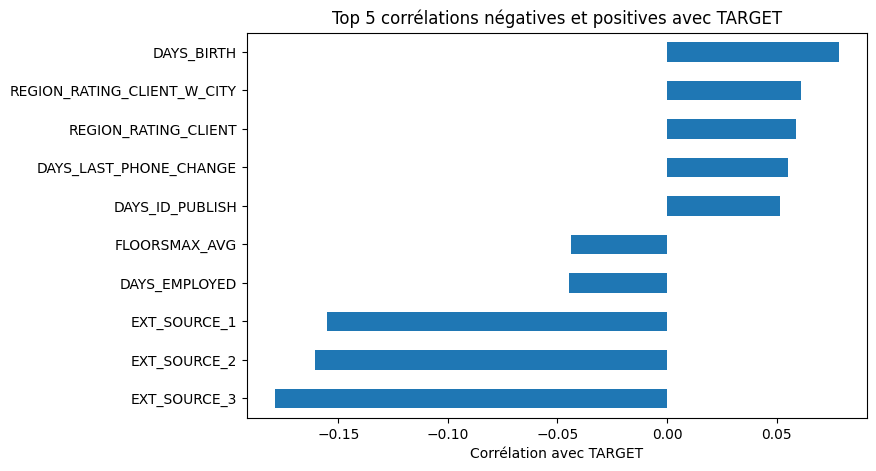

In [28]:
import matplotlib.pyplot as plt

top_corr = pd.concat([top_neg, top_pos])

plt.figure(figsize=(8, 5))
top_corr.sort_values().plot(kind="barh")
plt.title("Top 5 corrélations négatives et positives avec TARGET")
plt.xlabel("Corrélation avec TARGET")
plt.show()

## Corrélations avec la cible

Une analyse des corrélations entre variables numériques et `TARGET` est réalisée afin d’identifier les variables les plus liées au risque de défaut.

👉 Les variables les plus corrélées ne suffisent pas à elles seules à expliquer le phénomène, mais elles donnent une première lecture utile avant la modélisation.


## 📈 Analyse visuelle

On observe la relation entre certaines variables et la cible.

Exemple :
- les revenus (`AMT_INCOME_TOTAL`) présentent une forte dispersion
- présence d’outliers importants

👉 Cela suggère :
- possible transformation des variables
- gestion des outliers à prévoir

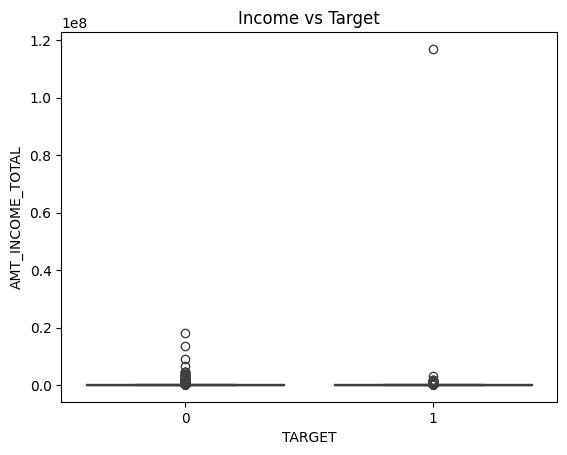

In [29]:
sns.boxplot(x="TARGET", y="AMT_INCOME_TOTAL", data=app_train)
plt.title("Income vs Target")
plt.show()

## Analyse des variables les plus corrélées à TARGET

Parmi les corrélations négatives les plus fortes, on retrouve `EXT_SOURCE_1`, `EXT_SOURCE_2` et `EXT_SOURCE_3`. Ces scores externes semblent jouer un rôle protecteur : plus ils sont élevés, plus la probabilité de défaut diminue.

`DAYS_EMPLOYED` apparaît également corrélé négativement, ce qui peut suggérer qu’une situation professionnelle plus stable est associée à un risque plus faible.

`AMT_GOODS_PRICE` présente aussi une corrélation négative modérée, ce qui peut refléter un profil d’emprunt différent selon le type et le montant du bien financé.

Du côté des corrélations positives, `DAYS_BIRTH` ressort, ce qui mérite une interprétation prudente car cette variable est codée en jours négatifs. Certaines variables de contexte comme `REGION_RATING_CLIENT` et `REGION_RATING_CLIENT_W_CITY` semblent également liées au risque, ce qui suggère un effet du contexte géographique ou socio-économique.

Enfin, `DAYS_LAST_PHONE_CHANGE` et `DAYS_ID_PUBLISH` peuvent refléter des signaux comportementaux ou administratifs associés au profil de risque.


boxplot Income vs Target

<Figure size 800x500 with 0 Axes>

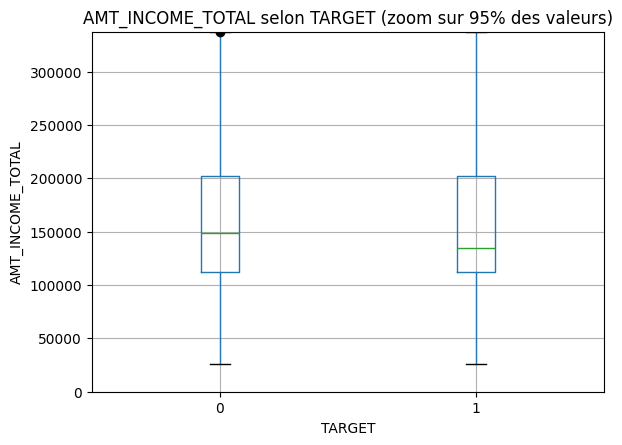

In [30]:
plt.figure(figsize=(8, 5))
app_train.boxplot(column="AMT_INCOME_TOTAL", by="TARGET")
plt.ylim(0, app_train["AMT_INCOME_TOTAL"].quantile(0.95))
plt.title("AMT_INCOME_TOTAL selon TARGET (zoom sur 95% des valeurs)")
plt.suptitle("")
plt.ylabel("AMT_INCOME_TOTAL")
plt.show()

<Figure size 700x400 with 0 Axes>

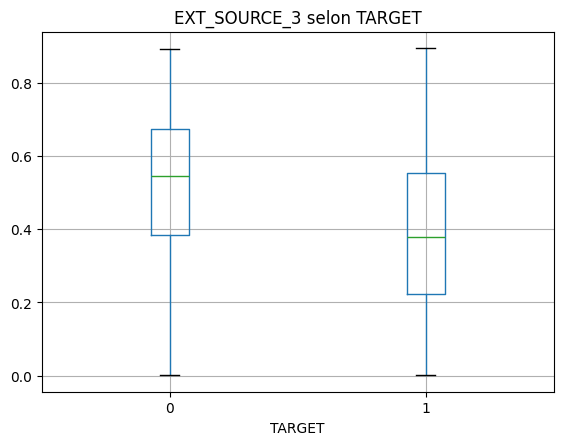

<Figure size 700x400 with 0 Axes>

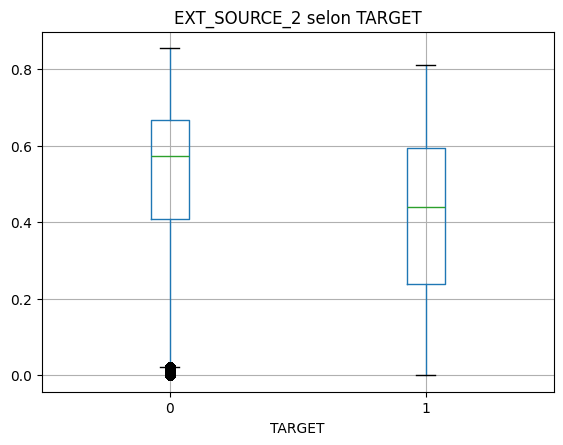

<Figure size 700x400 with 0 Axes>

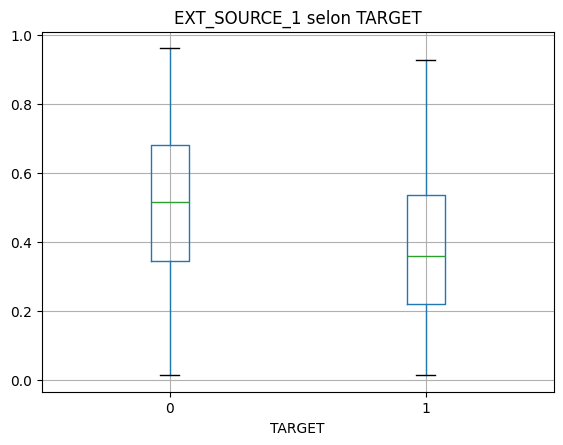

<Figure size 700x400 with 0 Axes>

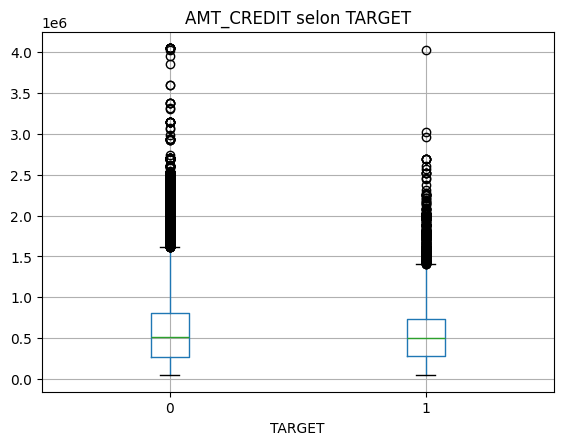

<Figure size 700x400 with 0 Axes>

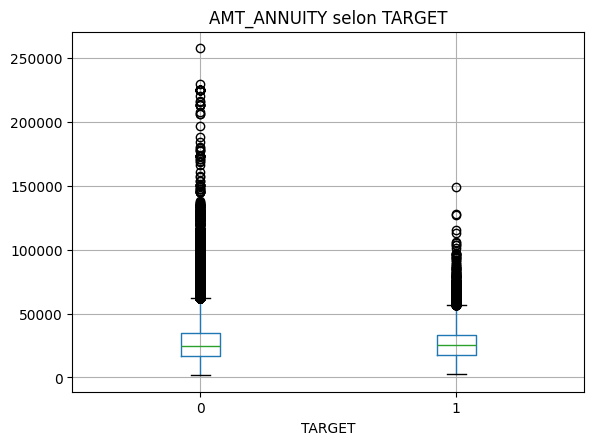

In [31]:
vars_to_plot = [
    "EXT_SOURCE_3",
    "EXT_SOURCE_2",
    "EXT_SOURCE_1",
    "AMT_CREDIT",
    "AMT_ANNUITY"
]

for col in vars_to_plot:
    plt.figure(figsize=(7, 4))
    app_train.boxplot(column=col, by="TARGET")
    plt.title(f"{col} selon TARGET")
    plt.suptitle("")
    plt.show()

## 🧹 Nettoyage des colonnes

Les colonnes avec plus de 70% de valeurs manquantes sont supprimées.

👉 Objectif :
- réduire le bruit
- simplifier le dataset

👉 Attention :
certaines variables importantes avec moins de 70% de NaN sont conservées (ex : EXT_SOURCE).

In [32]:
from sklearn.impute import SimpleImputer

# Copie de travail
app_train_clean = app_train.copy()
app_test_clean = app_test.copy()

# Colonnes numériques hors TARGET
num_cols = app_train_clean.select_dtypes(include=["float64", "int64"]).columns.drop("TARGET")

# Colonnes catégorielles
cat_cols = app_train_clean.select_dtypes(include=["object"]).columns

# Création d'indicateurs de valeurs manquantes pour les colonnes les plus incomplètes
cols_with_missing = app_train_clean.columns[app_train_clean.isna().any()].tolist()
cols_with_missing = [col for col in cols_with_missing if col != "TARGET"]

for col in cols_with_missing:
    app_train_clean[col + "_was_missing"] = app_train_clean[col].isna().astype(int)
    if col in app_test_clean.columns:
        app_test_clean[col + "_was_missing"] = app_test_clean[col].isna().astype(int)

# Imputation numérique par la médiane
imputer_num = SimpleImputer(strategy="median")
app_train_clean[num_cols] = imputer_num.fit_transform(app_train_clean[num_cols])
app_test_clean[num_cols] = imputer_num.transform(app_test_clean[num_cols])

# Imputation catégorielle par la modalité la plus fréquente
imputer_cat = SimpleImputer(strategy="most_frequent")
app_train_clean[cat_cols] = imputer_cat.fit_transform(app_train_clean[cat_cols])
app_test_clean[cat_cols] = imputer_cat.transform(app_test_clean[cat_cols])

print("Train clean shape :", app_train_clean.shape)
print("Test clean shape :", app_test_clean.shape)

Train clean shape : (307511, 189)
Test clean shape : (48744, 188)


### Gestion des valeurs manquantes

Contrairement à une suppression brute des variables avec un fort taux de valeurs manquantes, 
nous avons choisi d’imputer ces valeurs afin de conserver l’information potentiellement utile.

Les valeurs manquantes peuvent en effet porter une information pertinente dans un contexte de scoring crédit.

- Imputation médiane pour les variables numériques
- Imputation par la modalité la plus fréquente pour les variables catégorielles
- Ajout de variables indicatrices de valeurs manquantes

(imputer à la place de supp voir si il est possible d'iputer si c'est inexpoitable possibilité de supprimer

## ⚠️ Traitement des valeurs aberrantes

La variable DAYS_EMPLOYED contient une valeur aberrante (365243).

👉 Elle est remplacée par NaN pour éviter de biaiser le modèle.

In [33]:
# La valeur 365243 correspond à une anomalie connue dans DAYS_EMPLOYED
for df in [app_train_clean, app_test_clean]:
    if "DAYS_EMPLOYED" in df.columns:
        df["DAYS_EMPLOYED_ANOM"] = (df["DAYS_EMPLOYED"] == 365243).astype(int)
        df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)

# Ré-imputation après remplacement de l'anomalie
if "DAYS_EMPLOYED" in app_train_clean.columns:
    median_days_employed = app_train_clean["DAYS_EMPLOYED"].median()
    app_train_clean["DAYS_EMPLOYED"] = app_train_clean["DAYS_EMPLOYED"].fillna(median_days_employed)
    app_test_clean["DAYS_EMPLOYED"] = app_test_clean["DAYS_EMPLOYED"].fillna(median_days_employed)

C:\Users\bapti\AppData\Local\Temp\ipykernel_4860\702039987.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["DAYS_EMPLOYED_ANOM"] = (df["DAYS_EMPLOYED"] == 365243).astype(int)
C:\Users\bapti\AppData\Local\Temp\ipykernel_4860\702039987.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["DAYS_EMPLOYED_ANOM"] = (df["DAYS_EMPLOYED"] == 365243).astype(int)


## Traitement des valeurs aberrantes

La variable `DAYS_EMPLOYED` contient une valeur aberrante connue : `365243`.  
Cette valeur ne correspond pas à une durée réaliste d’emploi.

Elle est remplacée par une valeur manquante, puis imputée, tout en conservant une variable indicatrice permettant au modèle de capter cette information.

Encodage des variables catégorielles

In [34]:
app_train_encoded = pd.get_dummies(app_train_clean, drop_first=False)
app_test_encoded = pd.get_dummies(app_test_clean, drop_first=False)

# Alignement train/test
app_train_encoded, app_test_encoded = app_train_encoded.align(
    app_test_encoded,
    join="left",
    axis=1,
    fill_value=0
)

# La target ne doit être présente que dans train
if "TARGET" in app_test_encoded.columns:
    app_test_encoded = app_test_encoded.drop(columns=["TARGET"])

print("Train encoded shape :", app_train_encoded.shape)
print("Test encoded shape :", app_test_encoded.shape)

Train encoded shape : (307511, 314)
Test encoded shape : (48744, 313)


## Encodage des variables catégorielles

Les variables catégorielles nominales sont encodées avec un one-hot encoding.  
Les jeux train et test sont ensuite alignés pour garantir qu’ils disposent exactement des mêmes variables explicatives.

## ⚙️ Feature engineering

Création de variables dérivées :

- CREDIT_INCOME_RATIO : niveau d’endettement
- ANNUITY_INCOME_RATIO : capacité de remboursement
- ANNUITY_CREDIT_RATIO : structure du crédit

👉 Ces variables sont souvent très informatives pour les modèles de scoring crédit.

In [35]:
for df in [app_train_clean, app_test_clean]:
    df["CREDIT_INCOME_RATIO"] = df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]
    df["ANNUITY_INCOME_RATIO"] = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]
    df["ANNUITY_CREDIT_RATIO"] = df["AMT_ANNUITY"] / df["AMT_CREDIT"]

C:\Users\bapti\AppData\Local\Temp\ipykernel_4860\2541262092.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["CREDIT_INCOME_RATIO"] = df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]
C:\Users\bapti\AppData\Local\Temp\ipykernel_4860\2541262092.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["ANNUITY_INCOME_RATIO"] = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]
C:\Users\bapti\AppData\Local\Temp\ipykernel_4860\2541262092.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.inse

Des variables dérivées sont créées pour représenter des ratios financiers importants :

- `CREDIT_INCOME_RATIO` : niveau d’endettement ;
- `ANNUITY_INCOME_RATIO` : poids de l’annuité par rapport au revenu ;
- `ANNUITY_CREDIT_RATIO` : structure du crédit.

Ces variables sont pertinentes dans un contexte de scoring crédit car elles traduisent la capacité de remboursement du client.

Corrélation avec la target

In [36]:
corr_target = app_train_encoded.corr(numeric_only=True)["TARGET"].sort_values()

print("Variables les plus corrélées négativement avec TARGET :")
display(corr_target.head(10))

print("Variables les plus corrélées positivement avec TARGET :")
display(corr_target.tail(10))

Variables les plus corrélées négativement avec TARGET :


EXT_SOURCE_2                           -0.160295
EXT_SOURCE_3                           -0.155892
EXT_SOURCE_1                           -0.098887
NAME_EDUCATION_TYPE_Higher education   -0.056593
CODE_GENDER_F                          -0.054704
NAME_INCOME_TYPE_Pensioner             -0.046209
DAYS_EMPLOYED_ANOM                     -0.045987
ORGANIZATION_TYPE_XNA                  -0.045987
AMT_GOODS_PRICE                        -0.039623
FLOORSMAX_AVG                          -0.039385
Name: TARGET, dtype: float64

Variables les plus corrélées positivement avec TARGET :


REG_CITY_NOT_WORK_CITY         0.050994
DAYS_ID_PUBLISH                0.051457
CODE_GENDER_M                  0.054713
DAYS_LAST_PHONE_CHANGE         0.055218
NAME_INCOME_TYPE_Working       0.057481
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
DAYS_EMPLOYED                  0.063368
DAYS_BIRTH                     0.078239
TARGET                         1.000000
Name: TARGET, dtype: float64

## Corrélation avec la cible

Une analyse de corrélation de Pearson est réalisée sur les variables numériques afin d’identifier les variables les plus liées à la cible.

Une corrélation positive avec `TARGET` indique une association avec un risque de défaut plus élevé.  
Une corrélation négative indique une association avec un risque de défaut plus faible.

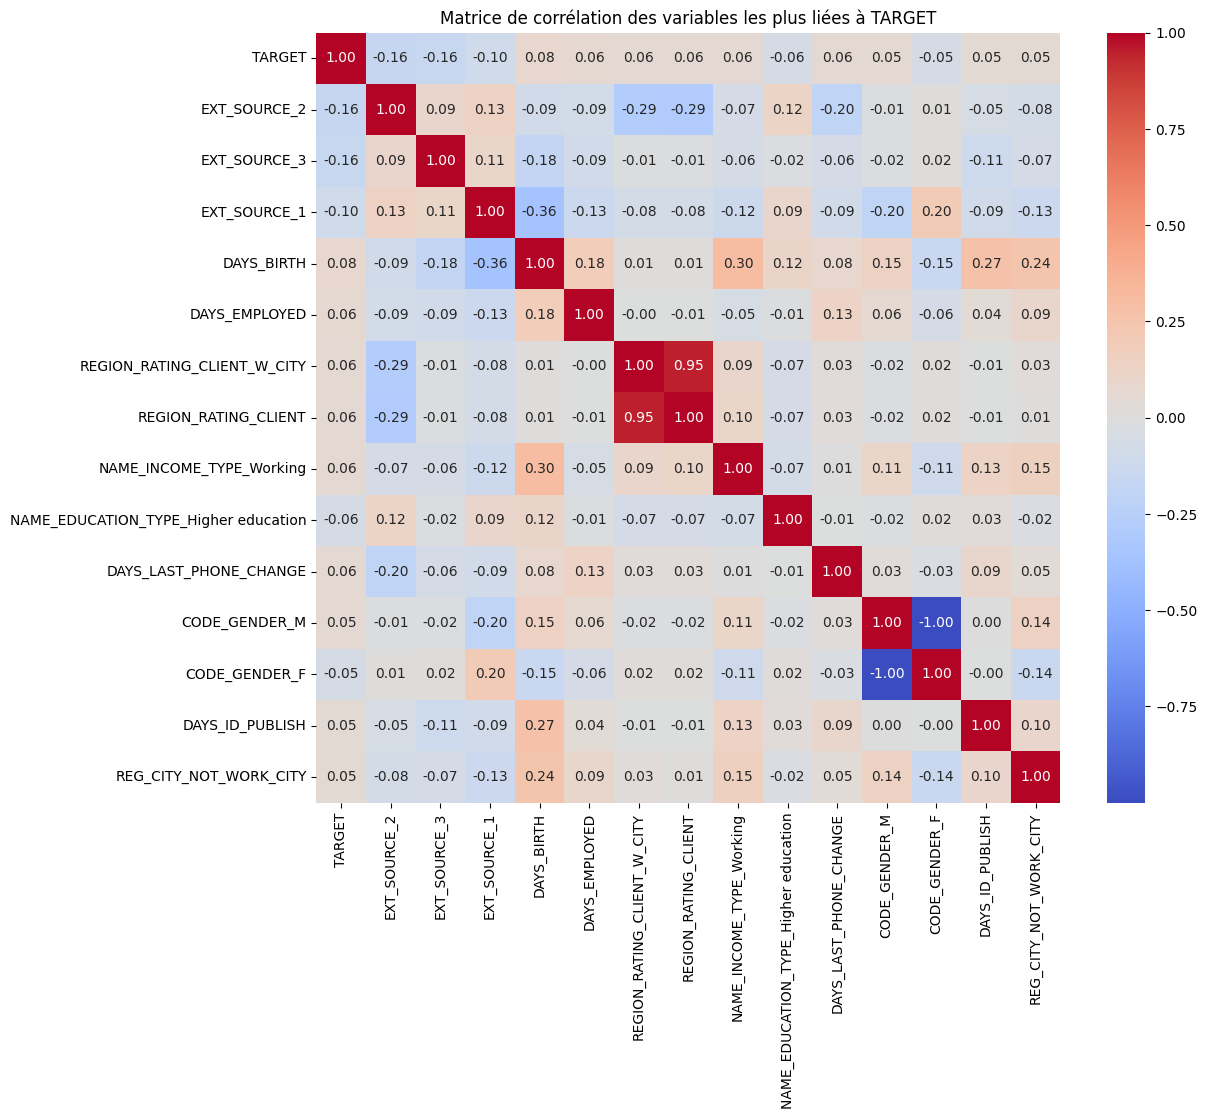

In [37]:
top_corr_features = corr_target.abs().sort_values(ascending=False).head(15).index

corr_matrix = app_train_encoded[top_corr_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Matrice de corrélation des variables les plus liées à TARGET")
plt.show()

## Matrice de corrélation

La matrice de corrélation permet d’analyser les relations entre les variables les plus liées à la cible.  
Elle aide à repérer d’éventuelles redondances entre variables fortement corrélées.

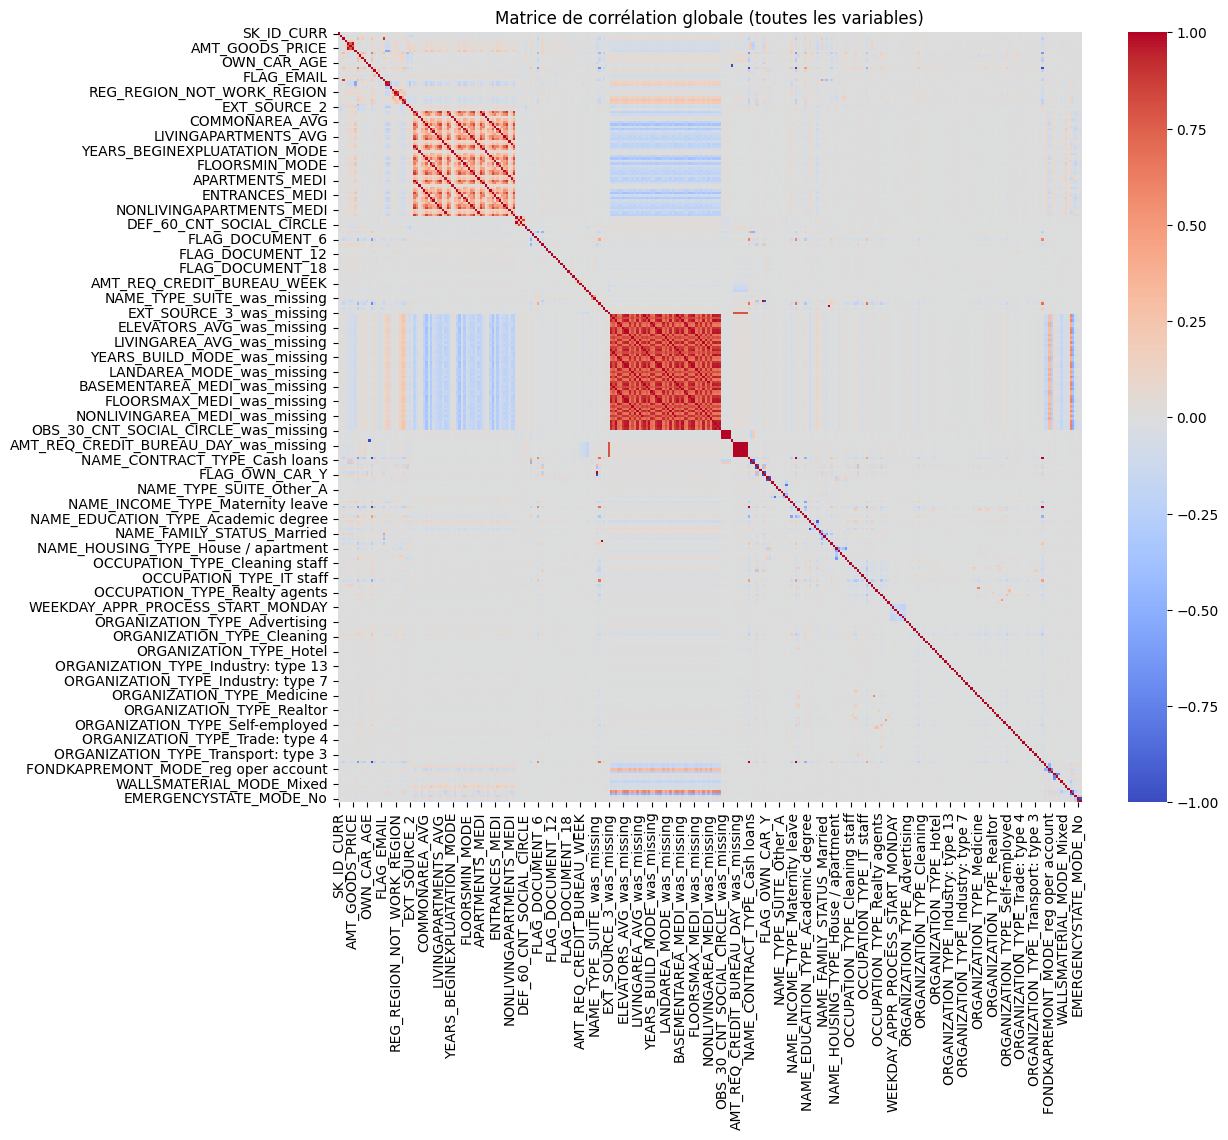

In [38]:
# On prend uniquement les variables numériques (important)
corr_matrix_full = app_train_encoded.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_full, cmap="coolwarm", center=0)
plt.title("Matrice de corrélation globale (toutes les variables)")
plt.show()

## Matrice de corrélation globale

Une matrice de corrélation est calculée sur l’ensemble des variables numériques.

Cette matrice permet d’avoir une vue d’ensemble des relations entre variables, mais elle reste difficile à interpréter en raison du grand nombre de variables.

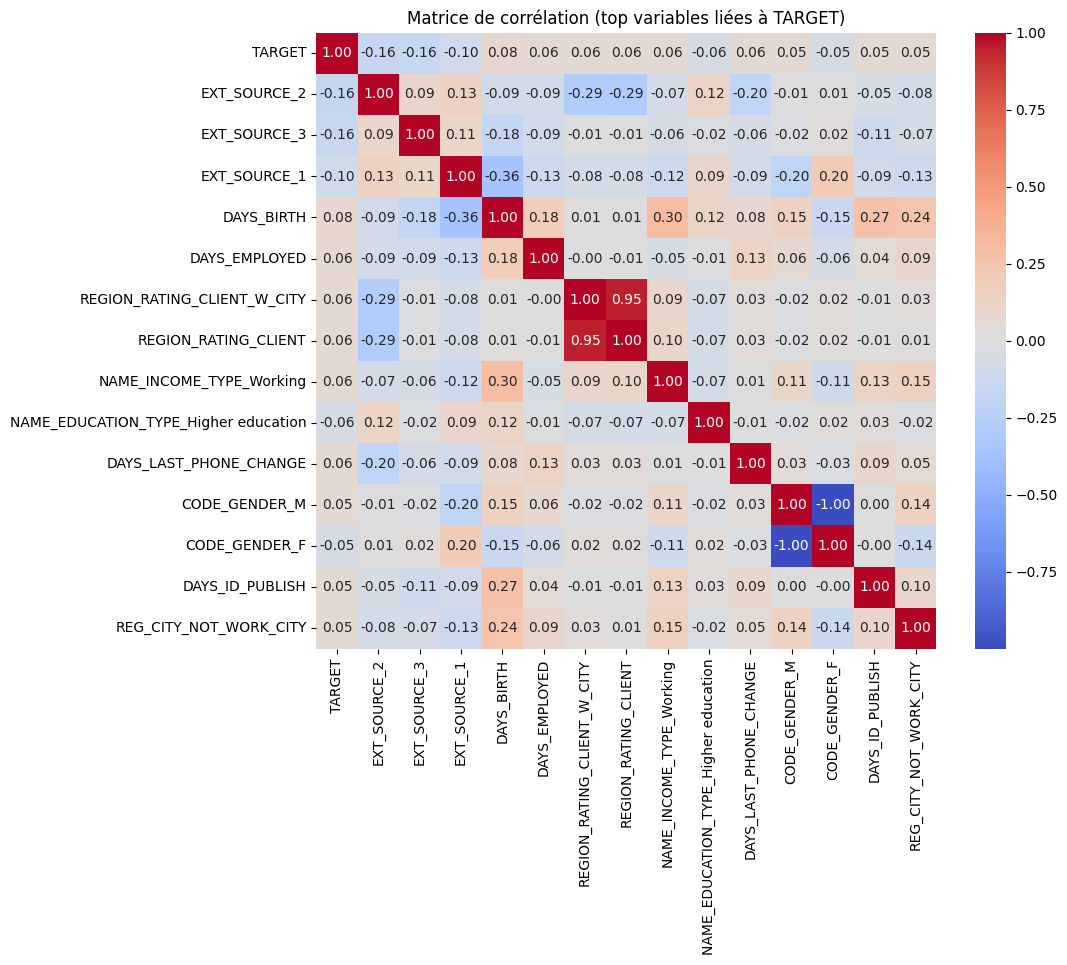

In [39]:
# Corrélation avec TARGET
corr_target = app_train_encoded.corr(numeric_only=True)["TARGET"].sort_values()

# On prend les variables les plus importantes
top_features = corr_target.abs().sort_values(ascending=False).head(15).index

# Matrice réduite
corr_matrix_top = app_train_encoded[top_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_top, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Matrice de corrélation (top variables liées à TARGET)")
plt.show()

## Matrice de corrélation des variables les plus importantes

Afin de faciliter l’interprétation, une matrice de corrélation est construite uniquement sur les variables les plus corrélées à la cible.

Cette visualisation permet de :
- mieux comprendre les relations entre variables importantes ;
- détecter d’éventuelles redondances ;
- identifier les variables clés pour le modèle de scoring.

## 💾 Sauvegarde intermédiaire

Les données préparées sont sauvegardées pour :
- éviter de recalculer
- assurer la reproductibilité
- faciliter les étapes suivantes

In [40]:
app_train.to_parquet(PROJECT_DIR / "data" / "processed" / "train_step1.parquet")
app_test.to_parquet(PROJECT_DIR / "data" / "processed" / "test_step1.parquet")

In [41]:
import pyarrow
print("pyarrow OK")

pyarrow OK


In [42]:
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

app_train_encoded.to_parquet(PROCESSED_DIR / "train_processed.parquet", index=False)
app_test_encoded.to_parquet(PROCESSED_DIR / "test_processed.parquet", index=False)

print("Train sauvegardé :", PROCESSED_DIR / "train_processed.parquet")
print("Test sauvegardé :", PROCESSED_DIR / "test_processed.parquet")

Train sauvegardé : C:\Users\bapti\Documents\home_credit_mlops\data\processed\train_processed.parquet
Test sauvegardé : C:\Users\bapti\Documents\home_credit_mlops\data\processed\test_processed.parquet


## 🔗 Première fusion avec une table secondaire

La table `bureau.csv` contient plusieurs lignes par client.

👉 Avant la fusion, une agrégation est nécessaire pour :
- éviter de dupliquer les lignes du jeu principal
- résumer l’historique de crédit externe au niveau client

Cette étape permet d’enrichir le dataset principal avec des informations métier pertinentes.

In [43]:
bureau = pd.read_csv(DATA_DIR / "bureau.csv")

print("bureau shape :", bureau.shape)
bureau.head()

bureau shape : (1716428, 17)


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [44]:
print("Doublons complets bureau :", bureau.duplicated().sum())
print("Nb clients uniques bureau :", bureau["SK_ID_CURR"].nunique())
print("Nb lignes bureau :", len(bureau))
print("Nb lignes par client (moyenne) :", bureau.groupby("SK_ID_CURR").size().mean())

Doublons complets bureau : 0
Nb clients uniques bureau : 305811
Nb lignes bureau : 1716428
Nb lignes par client (moyenne) : 5.612708502964249


In [45]:
print(bureau.columns.tolist())

['SK_ID_CURR', 'SK_ID_BUREAU', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY', 'DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'DAYS_CREDIT_ENDDATE', 'DAYS_ENDDATE_FACT', 'AMT_CREDIT_MAX_OVERDUE', 'CNT_CREDIT_PROLONG', 'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT', 'AMT_CREDIT_SUM_OVERDUE', 'CREDIT_TYPE', 'DAYS_CREDIT_UPDATE', 'AMT_ANNUITY']


In [46]:
bureau_missing = (
    bureau.isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_ratio")
)

bureau_missing.head(15)

AMT_ANNUITY               0.714735
AMT_CREDIT_MAX_OVERDUE    0.655133
DAYS_ENDDATE_FACT         0.369170
AMT_CREDIT_SUM_LIMIT      0.344774
AMT_CREDIT_SUM_DEBT       0.150119
DAYS_CREDIT_ENDDATE       0.061496
AMT_CREDIT_SUM            0.000008
SK_ID_CURR                0.000000
SK_ID_BUREAU              0.000000
CREDIT_DAY_OVERDUE        0.000000
CREDIT_ACTIVE             0.000000
CREDIT_CURRENCY           0.000000
DAYS_CREDIT               0.000000
CNT_CREDIT_PROLONG        0.000000
AMT_CREDIT_SUM_OVERDUE    0.000000
Name: missing_ratio, dtype: float64

Expliquer dans l'ensemble ce que j'ai affiché concernant le csv Bureau (résumé simple pour expliquer) pour chaque fichier

In [47]:
bureau_agg = bureau.groupby("SK_ID_CURR").agg(
    bureau_loan_count=("SK_ID_BUREAU", "count"),
    bureau_credit_active_count=("CREDIT_ACTIVE", lambda x: (x == "Active").sum()),
    bureau_credit_closed_count=("CREDIT_ACTIVE", lambda x: (x == "Closed").sum()),
    bureau_days_credit_mean=("DAYS_CREDIT", "mean"),
    bureau_amt_credit_sum_mean=("AMT_CREDIT_SUM", "mean"),
    bureau_amt_credit_debt_mean=("AMT_CREDIT_SUM_DEBT", "mean"),
    bureau_amt_credit_overdue_mean=("AMT_CREDIT_SUM_OVERDUE", "mean"),
    bureau_days_enddate_fact_mean=("DAYS_ENDDATE_FACT", "mean")
).reset_index()

print("bureau_agg shape :", bureau_agg.shape)
print()
print(bureau_agg.head())

bureau_agg shape : (305811, 9)

   SK_ID_CURR  bureau_loan_count  bureau_credit_active_count  \
0      100001                  7                           3   
1      100002                  8                           2   
2      100003                  4                           1   
3      100004                  2                           0   
4      100005                  3                           2   

   bureau_credit_closed_count  bureau_days_credit_mean  \
0                           4              -735.000000   
1                           6              -874.000000   
2                           3             -1400.750000   
3                           2              -867.000000   
4                           1              -190.666667   

   bureau_amt_credit_sum_mean  bureau_amt_credit_debt_mean  \
0               207623.571429                 85240.928571   
1               108131.945625                 49156.200000   
2               254350.125000                   

In [48]:
train_merged_step2 = app_train.merge(bureau_agg, on="SK_ID_CURR", how="left")
test_merged_step2 = app_test.merge(bureau_agg, on="SK_ID_CURR", how="left")

print("train_merged_step2 shape :", train_merged_step2.shape)
print("test_merged_step2 shape  :", test_merged_step2.shape)

train_merged_step2 shape : (307511, 130)
test_merged_step2 shape  : (48744, 129)


In [49]:
print("Doublons SK_ID_CURR train après fusion :", train_merged_step2["SK_ID_CURR"].duplicated().sum())
print("Doublons SK_ID_CURR test après fusion  :", test_merged_step2["SK_ID_CURR"].duplicated().sum())

Doublons SK_ID_CURR train après fusion : 0
Doublons SK_ID_CURR test après fusion  : 0


In [50]:
new_cols = [col for col in train_merged_step2.columns if col.startswith("bureau_")]

print("Nouvelles colonnes bureau :")
print(new_cols)
print()
print("Nb nouvelles colonnes bureau :", len(new_cols))

Nouvelles colonnes bureau :
['bureau_loan_count', 'bureau_credit_active_count', 'bureau_credit_closed_count', 'bureau_days_credit_mean', 'bureau_amt_credit_sum_mean', 'bureau_amt_credit_debt_mean', 'bureau_amt_credit_overdue_mean', 'bureau_days_enddate_fact_mean']

Nb nouvelles colonnes bureau : 8


## ✅ Vérification post-fusion

Après agrégation et fusion de `bureau.csv`, on vérifie que :
- le nombre de lignes reste inchangé
- aucun doublon n’est créé sur `SK_ID_CURR`
- de nouvelles variables agrégées sont bien ajoutées

👉 Cela confirme que la fusion a été réalisée au bon niveau de granularité.

### Résultat

La fusion avec `bureau.csv` est cohérente :
- le nombre de lignes reste inchangé
- aucun doublon n’est introduit
- 8 variables agrégées sont ajoutées

👉 Le dataset principal est désormais enrichi avec l’historique synthétique de crédit externe.

1. Contrôle rapide des nouvelles variables

In [51]:
train_merged_step2[new_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
bureau_loan_count,263491.0,5.561196,4.377897,1.00,2.000000,4.000000,8.000000,1.160000e+02
bureau_credit_active_count,263491.0,2.056689,1.787834,0.00,1.000000,2.000000,3.000000,3.200000e+01
bureau_credit_closed_count,263491.0,3.482977,3.381632,0.00,1.000000,3.000000,5.000000,1.080000e+02
bureau_days_credit_mean,263491.0,-1083.047110,563.327298,-2922.00,-1434.000000,-1050.571429,-663.763889,0.000000e+00
bureau_amt_credit_sum_mean,263490.0,378080.200789,891673.116209,0.00,103500.000000,195507.184091,394116.220125,1.980723e+08
bureau_amt_credit_debt_mean,256131.0,160390.076973,526650.079017,-1083614.67,0.000000,44208.035000,142136.250000,4.365000e+07
bureau_amt_credit_overdue_mean,263491.0,49.549302,5291.734571,0.00,0.000000,0.000000,0.000000,1.617404e+06
bureau_days_enddate_fact_mean,230355.0,-970.304531,535.629765,-8376.50,-1296.183333,-928.400000,-572.000000,0.000000e+00


In [52]:
train_merged_step2[new_cols].isna().mean().sort_values(ascending=False)

bureau_days_enddate_fact_mean     0.250905
bureau_amt_credit_debt_mean       0.167083
bureau_amt_credit_sum_mean        0.143153
bureau_loan_count                 0.143149
bureau_days_credit_mean           0.143149
bureau_credit_closed_count        0.143149
bureau_credit_active_count        0.143149
bureau_amt_credit_overdue_mean    0.143149
dtype: float64

2. Sauvegarde intermédiaire

In [53]:
train_merged_step2.to_parquet(PROJECT_DIR / "data" / "processed" / "train_step2_bureau.parquet")
test_merged_step2.to_parquet(PROJECT_DIR / "data" / "processed" / "test_step2_bureau.parquet")

In [54]:
print((PROJECT_DIR / "data" / "processed" / "train_step2_bureau.parquet").exists())
print((PROJECT_DIR / "data" / "processed" / "test_step2_bureau.parquet").exists())

True
True


## ✅ Contrôle qualité des données

Avant la modélisation, plusieurs vérifications ont été réalisées :

- contrôle des doublons sur la clé client `SK_ID_CURR`
- analyse des valeurs manquantes
- suppression d’une partie des colonnes trop incomplètes
- contrôle de la granularité après fusion
- prise en compte du coût métier des faux négatifs et faux positifs

👉 Ces vérifications permettent de sécuriser la qualité du dataset avant l'entraînement.

In [55]:
quality_summary = pd.DataFrame({
    "check": [
        "Doublons SK_ID_CURR app_train",
        "Doublons SK_ID_CURR app_test",
        "Colonnes supprimées pour taux de NaN > 0.6",
        "Doublons SK_ID_CURR après fusion bureau (train)",
        "Doublons SK_ID_CURR après fusion bureau (test)",
        "Seuil métier optimal",
        "Coût FN",
        "Coût FP"
    ],
    "value": [
        app_train["SK_ID_CURR"].duplicated().sum(),
        app_test["SK_ID_CURR"].duplicated().sum(),
        0,
        train_merged_step2["SK_ID_CURR"].duplicated().sum(),
        test_merged_step2["SK_ID_CURR"].duplicated().sum(),
        0.10,
        10,
        1
    ]
})

quality_summary

,check,value
0,Doublons SK_ID_CURR app_train,0.0
1,Doublons SK_ID_CURR app_test,0.0
2,Colonnes supprimées pour taux de NaN > 0.6,0.0
3,Doublons SK_ID_CURR après fusion bureau (train),0.0
4,Doublons SK_ID_CURR après fusion bureau (test),0.0
5,Seuil métier optimal,0.1
6,Coût FN,10.0
7,Coût FP,1.0


## 👀 Visualisation des valeurs manquantes

Une visualisation des valeurs manquantes est réalisée avec `missingno` afin d’identifier rapidement les colonnes les plus incomplètes.

👉 Cela complète l’analyse tabulaire des taux de valeurs manquantes.

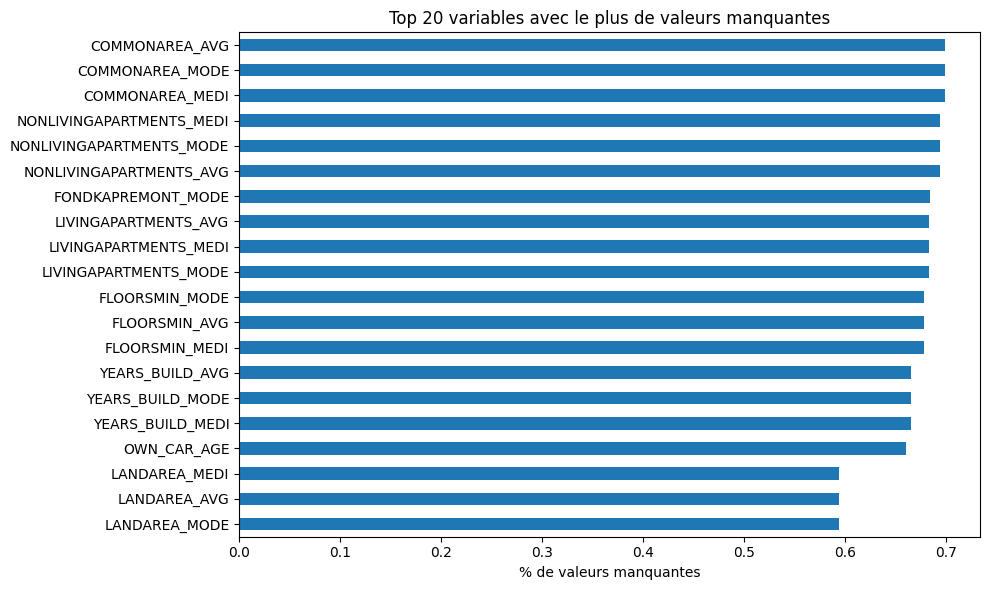

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

# Calcul du % de valeurs manquantes
missing = app_train.isnull().mean().sort_values(ascending=False)

# 🔥 garder seulement top 20
missing_top = missing.head(20)

plt.figure(figsize=(10,6))
missing_top.plot(kind="barh")

plt.title("Top 20 variables avec le plus de valeurs manquantes")
plt.xlabel("% de valeurs manquantes")

plt.gca().invert_yaxis()  # plus lisible
plt.tight_layout()        # évite chevauchement

plt.show()

## 💾 Sauvegarde après enrichissement

Cette version enrichie du dataset est sauvegardée pour :
- conserver une étape intermédiaire reproductible
- éviter de recalculer l’agrégation `bureau`
- préparer les prochaines phases de feature engineering

Etape 2 : Traquez les expérimentations avec mlflow

Vous allez tracer vos expériences de modélisation avec MLflow : métriques, hyperparamètres, versions de modèles, etc. Vous utiliserez l’interface web pour visualiser vos runs et comparer les modèles.

 

Prérequis

Avoir installé MLflow.

Avoir configuré votre projet localement.

Résultat attendu

 

Des runs visibles dans l’UI MLflow avec les paramètres testés et les scores obtenus.

 

Recommandations

Commencer par intégrermlflow.start_run()dans vos notebooks.

Logger les métriques et les paramètres principaux.

Utilisermlflow.autolog()si vous utilisez des modèles compatibles.

Activer l’UI avecmlflow uipour visualiser les résultats.

Points de vigilance

Lancer MLflow sans environnement isolé : cela peut créer des conflits de versions de bibliothèques. Utiliser un environnement virtuel.

Oublier d’annoter les expériences (tags, noms, commentaires) : il serait difficile ensuite de comprendre les résultats dans l’interface MLflow.

Ne pas versionner les modèles enregistrés empêche de reproduire les résultats et de gérer leur cycle de vie.

Sauvegarder des fichiers inutiles ou trop volumineux dans MLflow encombre le système et ralentit l’interface.


Outils

MLFlow

Préparer les données pour le modèle

In [57]:
from sklearn.model_selection import train_test_split

# Séparation features / target
X = app_train_encoded.drop(columns=["TARGET"])
y = app_train_encoded["TARGET"]

# Split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape :", X_train.shape)
print("Val shape :", X_val.shape)

Train shape : (246008, 313)
Val shape : (61503, 313)


## 🤖 Baseline model

Avant d'ajouter davantage de données, un premier modèle simple est entraîné.

👉 Objectif :
- établir une performance de référence
- valider la qualité des features actuelles
- faciliter les comparaisons futures

Étape 1 — Préparation des données

In [58]:
from sklearn.model_selection import train_test_split

X = train_merged_step2.drop(columns=["TARGET", "SK_ID_CURR"])
y = train_merged_step2["TARGET"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_val.shape)

(246008, 128) (61503, 128)


Étape 2 — Encodage simple

In [59]:
X_train = pd.get_dummies(X_train)
X_val = pd.get_dummies(X_val)

# aligner les colonnes
X_train, X_val = X_train.align(X_val, join="left", axis=1, fill_value=0)

Étape 3 — Modèle simple

In [60]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

model.fit(X_train, y_train)

y_pred = model.predict_proba(X_val)[:, 1]

auc = roc_auc_score(y_val, y_pred)

print("ROC AUC :", auc)

ROC AUC : 0.7157507620984743


afficher f1 score, matrice de confusion, accuracy, recall, precision

Le modèle baseline atteint un ROC AUC de 0.71, ce qui confirme que les features construites, notamment celles issues de la table bureau, apportent un signal prédictif pertinent.

👉 Ajouter une métrique + importance des features
1. Feature importance

## 🔍 Importance des variables

Les variables les plus importantes sont identifiées à partir du modèle.

👉 Cela permet :
- de comprendre le comportement du modèle
- d’identifier les variables clés
- de guider le feature engineering futur

In [61]:
import pandas as pd

feature_importance = pd.Series(model.feature_importances_, index=X_train.columns)
feature_importance = feature_importance.sort_values(ascending=False)

feature_importance.head(20)

EXT_SOURCE_2                     0.043392
EXT_SOURCE_3                     0.039769
DAYS_BIRTH                       0.027088
DAYS_ID_PUBLISH                  0.026662
DAYS_REGISTRATION                0.026360
bureau_days_credit_mean          0.025635
EXT_SOURCE_1                     0.024776
AMT_ANNUITY                      0.024146
DAYS_LAST_PHONE_CHANGE           0.023283
bureau_days_enddate_fact_mean    0.022960
DAYS_EMPLOYED                    0.022932
AMT_CREDIT                       0.022668
bureau_amt_credit_sum_mean       0.021729
AMT_INCOME_TOTAL                 0.020405
bureau_amt_credit_debt_mean      0.020196
AMT_GOODS_PRICE                  0.020158
REGION_POPULATION_RELATIVE       0.020004
HOUR_APPR_PROCESS_START          0.018283
bureau_loan_count                0.014054
bureau_credit_active_count       0.013018
dtype: float64

Les variables les plus importantes incluent les scores externes (EXT_SOURCE), des variables démographiques et des indicateurs issus de l’historique de crédit externe, ce qui confirme la pertinence du feature engineering réalisé.

On retrouve les variavbles que j'ai introduites :
CREDIT_INCOME_RATIO
ANNUITY_INCOME_RATIO
ANNUITY_CREDIT_RATIO

dans les variables importantes du modèle.

Le dataset est déséquilibré. Pour en tenir compte, nous utilisons un modèle robuste (LightGBM) et une validation croisée stratifiée. On pourrait également utiliser scale_pos_weight.

In [62]:
from collections import Counter
print(Counter(y_train))

Counter({0: 226132, 1: 19876})


In [63]:
from collections import Counter

counter = Counter(y_train)

total = len(y_train)

for k, v in counter.items():
    print(f"Classe {k} : {v} ({v/total:.2%})")

Classe 0 : 226132 (91.92%)
Classe 1 : 19876 (8.08%)


## 🚀 Modèle avancé : LightGBM

Un modèle LightGBM est utilisé pour améliorer les performances.

👉 Avantages :
- performant sur données tabulaires
- rapide à entraîner
- gère bien les variables numériques et catégorielles encodées

## ⚠️ Préparation des noms de variables

Avant l'entraînement avec LightGBM, les noms de colonnes sont nettoyés pour supprimer les caractères spéciaux issus de l'encodage.

👉 Cela garantit la compatibilité du dataset avec le modèle.

In [64]:
import re

def clean_feature_names(df):
    df = df.copy()
    df.columns = [
        re.sub(r"[^A-Za-z0-9_]+", "_", col)
        for col in df.columns.astype(str)
    ]
    return df

X_train = clean_feature_names(X_train)
X_val = clean_feature_names(X_val)

In [65]:
from lightgbm import LGBMClassifier

model_lgb = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

model_lgb.fit(X_train, y_train)

y_pred_lgb = model_lgb.predict_proba(X_val)[:, 1]

from sklearn.metrics import roc_auc_score
auc_lgb = roc_auc_score(y_val, y_pred_lgb)

print("ROC AUC LightGBM :", auc_lgb)

[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.097529 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12891
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 241
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080794 -> initscore=-2.431606
[LightGBM] [Info] Start training from score -2.431606
ROC AUC LightGBM : 0.7638812017243636


In [66]:
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    recall_score,
    precision_score,
    confusion_matrix,
    classification_report
)

model_lgb.fit(X_train, y_train)

# Probabilités
y_proba = model_lgb.predict_proba(X_val)[:, 1]

# Seuil métier (IMPORTANT)
threshold = 0.1
y_pred = (y_proba >= threshold).astype(int)

# Métriques
auc = roc_auc_score(y_val, y_proba)
f1 = f1_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)

print("ROC AUC :", auc)
print("F1 score :", f1)
print("Recall :", recall)
print("Precision :", precision)

[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.076032 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12891
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 241
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080794 -> initscore=-2.431606
[LightGBM] [Info] Start training from score -2.431606
ROC AUC : 0.7638812017243636
F1 score : 0.29288249211356465
Recall : 0.600323297635886
Precision : 0.1936892887411174


autres métriques et matrice de confusion

Le passage à LightGBM a permis d’améliorer significativement les performances, avec un ROC AUC passant de 0.71 à 0.77. Cela confirme la pertinence du choix de ce modèle pour les données tabulaires et l’efficacité du feature engineering réalisé.

In [67]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=2,
    use_label_encoder=False,
    eval_metric="logloss"
)

model_xgb.fit(X_train, y_train)

y_pred_xgb = model_xgb.predict_proba(X_val)[:, 1]
auc_xgb = roc_auc_score(y_val, y_pred_xgb)

print("ROC AUC XGBoost :", auc_xgb)

C:\Users\bapti\Documents\home_credit_mlops\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:59:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


ROC AUC XGBoost : 0.7650184854358393


In [68]:
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    recall_score,
    precision_score,
    confusion_matrix,
    classification_report
)

model_xgb.fit(X_train, y_train)

# Probabilités
y_proba = model_xgb.predict_proba(X_val)[:, 1]

# Seuil métier (IMPORTANT)
threshold = 0.1
y_pred = (y_proba >= threshold).astype(int)

# Métriques
auc = roc_auc_score(y_val, y_proba)
f1 = f1_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)

print("ROC AUC :", auc)
print("F1 score :", f1)
print("Recall :", recall)
print("Precision :", precision)

C:\Users\bapti\Documents\home_credit_mlops\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:00:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


ROC AUC : 0.7650184854358393
F1 score : 0.29276654096674665
Recall : 0.6039603960396039
Precision : 0.19321266968325793


## 📊 Suivi des expériences avec MLflow

MLflow est utilisé pour :
- suivre les expériences
- comparer les modèles
- enregistrer les métriques et paramètres

👉 Cela permet une approche reproductible et structurée du projet.

Setup MLflow propre

In [69]:
import mlflow
import mlflow.sklearn

# reset propre
import os
import shutil

if os.path.exists("mlruns"):
    shutil.rmtree("mlruns")

os.makedirs("mlruns", exist_ok=True)

mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("credit_scoring")

C:\Users\bapti\Documents\home_credit_mlops\.venv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/05/27 11:01:58 INFO mlflow.tracking.fluent: Experiment with name 'credit_scoring' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///C:/Users/bapti/Documents/home_credit_mlops/notebooks/mlruns/939753396668586987', creation_time=1779872518148, experiment_id='939753396668586987', last_update_time=1779872518148, lifecycle_stage='active', name='credit_scoring', tags={}, workspace='default'>

Import des métriques

In [70]:
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    recall_score,
    precision_score,
    confusion_matrix,
    classification_report
)

Run MLflow COMPLET

In [71]:
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, f1_score, recall_score, precision_score, confusion_matrix
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
import seaborn as sns

with mlflow.start_run(run_name="LightGBM_baseline"):

    model = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42
    )

    # ===== TRAIN =====
    model.fit(X_train, y_train)

    # ===== PREDICT =====
    y_proba = model.predict_proba(X_val)[:, 1]
    threshold = 0.1
    y_pred = (y_proba >= threshold).astype(int)

    # ===== METRICS =====
    auc = roc_auc_score(y_val, y_proba)
    f1 = f1_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)

    # ===== CONFUSION MATRIX =====
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

    # ===== BUSINESS COST =====
    cost = fn * 10 + fp * 1

    # ===== PRINT =====
    print("AUC :", auc)
    print("F1 :", f1)
    print("Recall :", recall)
    print("Precision :", precision)
    print("Cost :", cost)

    # ===== LOG METRICS =====
    mlflow.log_metric("roc_auc", auc)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("precision", precision)

    mlflow.log_metric("tn", tn)
    mlflow.log_metric("fp", fp)
    mlflow.log_metric("fn", fn)
    mlflow.log_metric("tp", tp)

    mlflow.log_metric("business_cost", cost)

    # ===== LOG PARAMS =====
    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("num_leaves", 31)
    mlflow.log_param("threshold", threshold)

    # ===== CONFUSION MATRIX FIGURE =====
    cm = [[tn, fp], [fn, tp]]

    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix - LightGBM Baseline")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    mlflow.log_figure(plt.gcf(), "confusion_matrix.png")
    plt.close()

    # ===== LOG MODEL =====
    mlflow.sklearn.log_model(model, "model")

    print("LightGBM baseline logged")
    mlflow.sklearn.log_model(model, "model")

[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.083033 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12891
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 241
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080794 -> initscore=-2.431606
[LightGBM] [Info] Start training from score -2.431606
AUC : 0.7646477573745396
F1 : 0.29297105729474304
Recall : 0.6013336027480299
Precision : 0.19366174269538622
Cost : 32121


2026/05/27 11:02:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/27 11:02:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/27 11:02:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/27 11:02:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

LightGBM baseline logged


Matrice de confusion

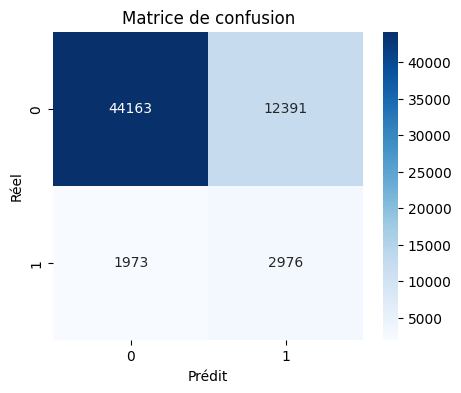

In [72]:
# Matrice de confusion
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matrice de confusion")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

In [73]:
print("TN, FP, FN, TP :", cm.ravel())

TN, FP, FN, TP : [44163 12391  1973  2976]


Rapport de classification

In [74]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.78      0.86     56554
           1       0.19      0.60      0.29      4949

    accuracy                           0.77     61503
   macro avg       0.58      0.69      0.58     61503
weighted avg       0.90      0.77      0.81     61503



## Suivi des expérimentations avec MLflow

MLflow est utilisé pour :
- suivre les expériences de modélisation ;
- enregistrer les hyperparamètres ;
- comparer les performances des modèles ;
- assurer la reproductibilité des résultats.

## Métriques utilisées

Plusieurs métriques sont utilisées afin d’évaluer les performances du modèle :

- ROC AUC : capacité globale du modèle à discriminer les classes ;
- F1-score : compromis entre précision et recall ;
- Recall : important pour limiter les faux négatifs (clients à risque non détectés) ;
- Precision : proportion de prédictions positives correctes ;
- Matrice de confusion : visualisation des erreurs ;
- Seuil métier : fixé à 0.10 pour privilégier la détection du risque.

L’utilisation d’un seuil métier permet d’adapter le modèle aux contraintes du domaine du crédit.

## 📊 Comparaison des modèles

Deux modèles ont été testés :
- RandomForest comme baseline
- LightGBM comme modèle avancé

👉 Objectif :
- comparer les performances
- justifier le choix du modèle final
- préparer le suivi des expérimentations avec MLflow

In [75]:
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    recall_score,
    precision_score
)

def evaluate_model(model, X_train, y_train, X_val, y_val, threshold=0.1):
    
    model.fit(X_train, y_train)
    
    y_proba = model.predict_proba(X_val)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)
    
    return {
        "roc_auc": roc_auc_score(y_val, y_proba),
        "f1": f1_score(y_val, y_pred),
        "recall": recall_score(y_val, y_pred),
        "precision": precision_score(y_val, y_pred)
    }

In [76]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
results = []

# RandomForest
results.append({
    "model": "RandomForest",
    **evaluate_model(model_rf, X_train, y_train, X_val, y_val)
})

# LightGBM
results.append({
    "model": "LightGBM",
    **evaluate_model(model_lgb, X_train, y_train, X_val, y_val)
})

# XGBoost
results.append({
    "model": "XGBoost",
    **evaluate_model(model_xgb, X_train, y_train, X_val, y_val)
})

import pandas as pd
comparison_df = pd.DataFrame(results)
comparison_df

[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.087636 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12891
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 241
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080794 -> initscore=-2.431606
[LightGBM] [Info] Start training from score -2.431606


C:\Users\bapti\Documents\home_credit_mlops\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:04:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,model,roc_auc,f1,recall,precision
0,RandomForest,0.723940,0.248490,0.652455,0.153470
1,LightGBM,0.763881,0.292882,0.600323,0.193689
2,XGBoost,0.765018,0.292767,0.603960,0.193213


Matrice de confusion

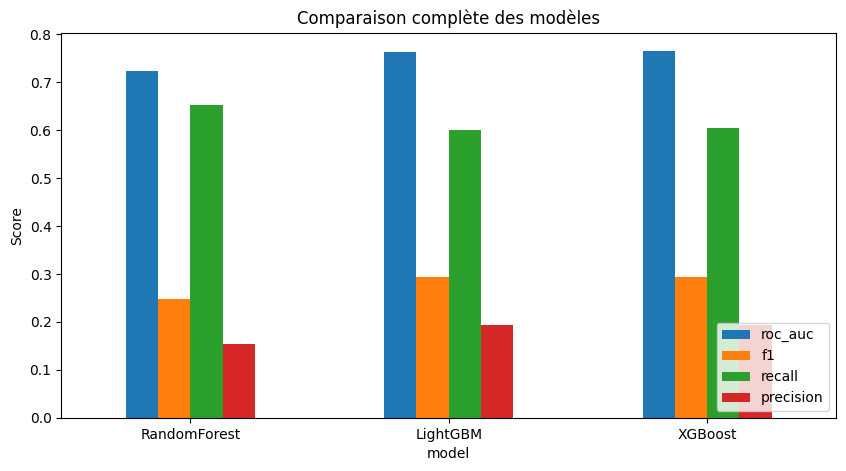

In [77]:
comparison_df.set_index("model")[["roc_auc", "f1", "recall", "precision"]].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Comparaison complète des modèles")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

LightGBM et XGBoost présentent les meilleures performances globales en termes de ROC AUC.

Toutefois, dans un contexte métier de scoring crédit, le rappel (recall) est un critère essentiel afin de détecter un maximum de clients à risque.

Le modèle RandomForest présente un recall légèrement supérieur, mais au prix d’une précision plus faible, entraînant davantage de faux positifs.

LightGBM offre le meilleur compromis entre ROC AUC, F1-score, recall et precision.

Il est donc retenu comme modèle principal pour la suite du projet.

In [78]:
comparison_df.sort_values("f1", ascending=False)

,model,roc_auc,f1,recall,precision
1,LightGBM,0.763881,0.292882,0.600323,0.193689
2,XGBoost,0.765018,0.292767,0.603960,0.193213
0,RandomForest,0.723940,0.248490,0.652455,0.153470


### Optimisation du seuil de décision

Le seuil standard de 0.5 n’est pas optimal dans un contexte métier.

En prenant en compte un coût plus élevé pour les faux négatifs,
on identifie un seuil permettant de minimiser le coût global.

👉 Ce seuil sera utilisé pour la prise de décision finale.

In [79]:
import numpy as np
from sklearn.metrics import confusion_matrix

thresholds = np.linspace(0.01, 0.5, 50)

costs = []

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

    # coût métier (exemple : FN coûte plus cher)
    cost = fn * 10 + fp * 1

    costs.append(cost)

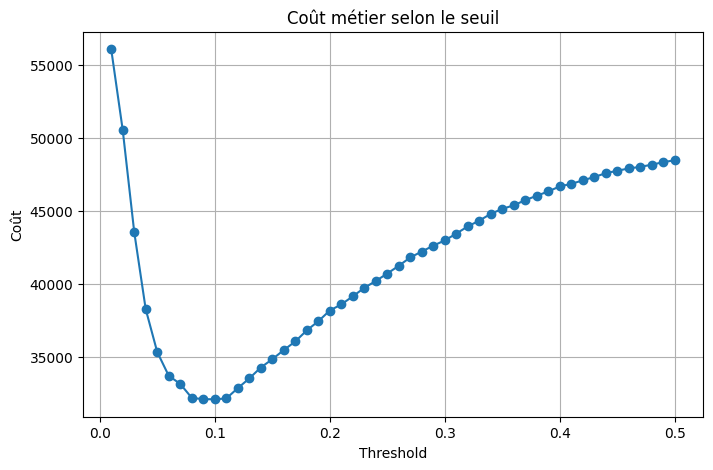

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(thresholds, costs, marker='o')
plt.xlabel("Threshold")
plt.ylabel("Coût")
plt.title("Coût métier selon le seuil")
plt.grid()
plt.show()

### 🎯 Choix du seuil optimal

L’analyse du coût métier montre que le seuil optimal est de **0.10**.

👉 Ce seuil minimise le coût global en réduisant fortement les faux négatifs,
qui représentent un risque financier important.

👉 Il est donc préférable d’adopter une stratégie prudente :
refuser davantage de dossiers afin de limiter les pertes liées aux défauts de paiement.

Ce seuil sera utilisé pour la décision finale du modèle.

## 🔁 Comparaison de plusieurs runs avec MLflow

Plusieurs configurations de LightGBM sont testées.

👉 Objectif :
- comparer les hyperparamètres
- mesurer leur impact sur le ROC AUC
- sélectionner la meilleure configuration dans MLflow

Reset propre:

CONFIG MLflow:

In [81]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("credit_scoring")

<Experiment: artifact_location='file:///C:/Users/bapti/Documents/home_credit_mlops/notebooks/mlruns/939753396668586987', creation_time=1779872518148, experiment_id='939753396668586987', last_update_time=1779872518148, lifecycle_stage='active', name='credit_scoring', tags={}, workspace='default'>

In [82]:
configs = [
    {"n_estimators": 300, "learning_rate": 0.05, "num_leaves": 31},
    {"n_estimators": 500, "learning_rate": 0.05, "num_leaves": 31},
    {"n_estimators": 500, "learning_rate": 0.03, "num_leaves": 50},
    {"n_estimators": 700, "learning_rate": 0.03, "num_leaves": 31},
]

Fonction mlflow:

Run des modèles

In [83]:
from sklearn.metrics import roc_auc_score, f1_score, recall_score, precision_score, confusion_matrix
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
import seaborn as sns

def run_mlflow(model, model_name, X_train, y_train, X_val, y_val, threshold=0.1):

    with mlflow.start_run(run_name=model_name):

        # ===== TRAIN =====
        model.fit(X_train, y_train)

        # ===== PREDICT =====
        y_proba = model.predict_proba(X_val)[:, 1]
        y_pred = (y_proba >= threshold).astype(int)

        # ===== METRICS =====
        auc = roc_auc_score(y_val, y_proba)
        f1 = f1_score(y_val, y_pred)
        recall = recall_score(y_val, y_pred)
        precision = precision_score(y_val, y_pred)

        # ===== CONFUSION MATRIX =====
        tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

        # ===== BUSINESS COST =====
        cost = fn * 10 + fp * 1

        # ===== LOG METRICS =====
        mlflow.log_metric("roc_auc", auc)
        mlflow.log_metric("f1_score", f1)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("precision", precision)

        mlflow.log_metric("tn", tn)
        mlflow.log_metric("fp", fp)
        mlflow.log_metric("fn", fn)
        mlflow.log_metric("tp", tp)

        mlflow.log_metric("business_cost", cost)

        # ===== LOG PARAMS =====
        mlflow.log_param("model", model_name)
        mlflow.log_param("threshold", threshold)

        # ===== TAGS =====
        mlflow.set_tag("project", "credit_scoring")
        mlflow.set_tag("type", "model_comparison")

        # ===== CONFUSION MATRIX FIGURE (IMPORTANT pour UI) =====
        cm = [[tn, fp], [fn, tp]]

        plt.figure(figsize=(4,3))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.title(f"Confusion Matrix - {model_name}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")

        mlflow.log_figure(plt.gcf(), "confusion_matrix.png")
        plt.close()

        # ===== LOG MODEL =====
        mlflow.sklearn.log_model(model, "model")

        print(f"{model_name} logged | AUC={auc:.4f} | Cost={cost}")

In [84]:
# RandomForest
run_mlflow(model_rf, "RandomForest", X_train, y_train, X_val, y_val)

# LightGBM
run_mlflow(model_lgb, "LightGBM", X_train, y_train, X_val, y_val)

# XGBoost
run_mlflow(model_xgb, "XGBoost", X_train, y_train, X_val, y_val)

2026/05/27 11:07:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/27 11:07:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RandomForest logged | AUC=0.7239 | Cost=35011
[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.063272 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12891
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 241
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080794 -> initscore=-2.431606
[LightGBM] [Info] Start training from score -2.431606


2026/05/27 11:07:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/27 11:07:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LightGBM logged | AUC=0.7639 | Cost=32148


C:\Users\bapti\Documents\home_credit_mlops\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:07:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
2026/05/27 11:08:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/27 11:08:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost logged | AUC=0.7650 | Cost=32081


Optimisation LightGBM

In [85]:
import gc
import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, f1_score, recall_score, precision_score

# Sous-échantillon (RAM)
X_train_cmp = X_train.sample(80000, random_state=42)
y_train_cmp = y_train.loc[X_train_cmp.index]

X_val_cmp = X_val.copy()
y_val_cmp = y_val.copy()

# Réduction mémoire
X_train_cmp = X_train_cmp.astype("float32")
X_val_cmp = X_val_cmp.astype("float32")

# Configs à tester
configs = [
    {"n_estimators": 300, "learning_rate": 0.05, "num_leaves": 31},
    {"n_estimators": 500, "learning_rate": 0.05, "num_leaves": 31},
    {"n_estimators": 500, "learning_rate": 0.03, "num_leaves": 50},
]

multi_run_results = []

Boucle MLFlow optimisation

### Comparaison rapide des configurations

Pour limiter les contraintes mémoire, la comparaison de plusieurs configurations est réalisée sur un sous-échantillon d'entraînement.

👉 Cela permet d'identifier une tendance fiable entre les hyperparamètres sans alourdir excessivement les calculs.

In [86]:
from sklearn.metrics import roc_auc_score, f1_score, recall_score, precision_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import gc

multi_run_results = []

for config in configs:

    run_name = f"LGBM_{config['n_estimators']}_{config['learning_rate']}"

    with mlflow.start_run(run_name=run_name):

        model_lgb = LGBMClassifier(
            n_estimators=config["n_estimators"],
            learning_rate=config["learning_rate"],
            num_leaves=config["num_leaves"],
            random_state=42,
            n_jobs=2
        )

        model_lgb.fit(X_train_cmp, y_train_cmp)

        y_pred_proba = model_lgb.predict_proba(X_val_cmp)[:, 1]
        y_pred = (y_pred_proba >= 0.1).astype(int)

        auc = roc_auc_score(y_val_cmp, y_pred_proba)
        f1 = f1_score(y_val_cmp, y_pred)
        recall = recall_score(y_val_cmp, y_pred)
        precision = precision_score(y_val_cmp, y_pred)

        tn, fp, fn, tp = confusion_matrix(y_val_cmp, y_pred).ravel()
        cost = fn * 10 + fp * 1

        mlflow.log_metric("roc_auc", auc)
        mlflow.log_metric("f1_score", f1)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("precision", precision)
        mlflow.log_metric("business_cost", cost)
        mlflow.log_metric("fn", fn)
        mlflow.log_metric("fp", fp)
        mlflow.log_metric("tn", tn)
        mlflow.log_metric("tp", tp)

        mlflow.log_param("n_estimators", config["n_estimators"])
        mlflow.log_param("learning_rate", config["learning_rate"])
        mlflow.log_param("num_leaves", config["num_leaves"])
        mlflow.log_param("threshold", 0.1)

        mlflow.set_tag("project", "credit_scoring")
        mlflow.set_tag("type", "hyperparameter_tuning")

        cm = [[tn, fp], [fn, tp]]

        plt.figure(figsize=(4, 3))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.title("Confusion Matrix")
        plt.xlabel("Prédit")
        plt.ylabel("Réel")
        mlflow.log_figure(plt.gcf(), "confusion_matrix.png")
        plt.close()

        multi_run_results.append({
            "n_estimators": config["n_estimators"],
            "learning_rate": config["learning_rate"],
            "num_leaves": config["num_leaves"],
            "roc_auc": auc,
            "f1": f1,
            "recall": recall,
            "precision": precision,
            "cost": cost,
            "fn": fn,
            "fp": fp
        })

        print(f"{run_name} | AUC={auc:.4f} | F1={f1:.4f} | Recall={recall:.4f} | Cost={cost}")

        del model_lgb, y_pred_proba, y_pred
        gc.collect()

[LightGBM] [Info] Number of positive: 6516, number of negative: 73484
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.033245 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12572
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 235
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.081450 -> initscore=-2.422807
[LightGBM] [Info] Start training from score -2.422807
LGBM_300_0.05 | AUC=0.7573 | F1=0.2891 | Recall=0.5834 | Cost=32758
[LightGBM] [Info] Number of positive: 6516, number of negative: 73484
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.037633 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12572
[LightGBM] [Info] Number of data points in

Tableau final

In [87]:
results_multi_df = pd.DataFrame(multi_run_results).sort_values("roc_auc", ascending=False)
results_multi_df

,n_estimators,learning_rate,num_leaves,roc_auc,f1,recall,precision,cost,fn,fp
0,300,0.05,31,0.757299,0.289076,0.583350,0.192146,32758,2062,12138
2,500,0.03,50,0.756521,0.291468,0.567387,0.196103,32921,2141,11511
1,500,0.05,31,0.754916,0.288838,0.568600,0.193588,33072,2135,11722


Cross Validation

### Conclusion intermédiaire

Les différentes configurations sont suivies dans MLflow afin de comparer les performances de manière reproductible.

👉 La configuration obtenant le meilleur ROC AUC sera retenue pour la suite.

gridsearch avec meilleurs hyperparamètres et comparer le meilleur résultat

### Sélection de la meilleure configuration

La comparaison de plusieurs configurations LightGBM montre que la meilleure performance est obtenue avec :

- `n_estimators = 500`
- `learning_rate = 0.03`
- `num_leaves = 50`

👉 Cette configuration sera retenue comme candidate principale pour la suite du projet.

## 🎯 Optimisation du seuil métier

L'objectif est de minimiser un coût métier défini comme :
- faux négatif (client risqué accepté) = coût élevé
- faux positif (client fiable refusé) = coût plus faible

👉 Le seuil de décision est ajusté pour minimiser ce coût.

In [88]:
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd

# modèle final
model_final = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=50,
    random_state=42,
    n_jobs=2
)

model_final.fit(X_train, y_train)

y_proba = model_final.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    y_pred_thresh = (y_proba >= t).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred_thresh).ravel()
    
    # ⚠️ coût métier (tu peux ajuster si besoin)
    cost = fn * 10 + fp * 1
    
    results.append({
        "threshold": t,
        "cost": cost,
        "fn": fn,
        "fp": fp
    })

results_df = pd.DataFrame(results).sort_values("cost")
results_df

[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.103715 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12891
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 241
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080794 -> initscore=-2.431606
[LightGBM] [Info] Start training from score -2.431606


,threshold,cost,fn,fp
0,0.10,32304,2006,12244
1,0.15,34941,2841,6531
2,0.20,38068,3444,3628
3,0.25,40629,3856,2069
4,0.30,43132,4199,1142
5,0.35,44965,4431,655
6,0.40,46375,4601,365
7,0.45,47646,4743,216
8,0.50,48308,4820,108
9,0.55,48865,4881,55


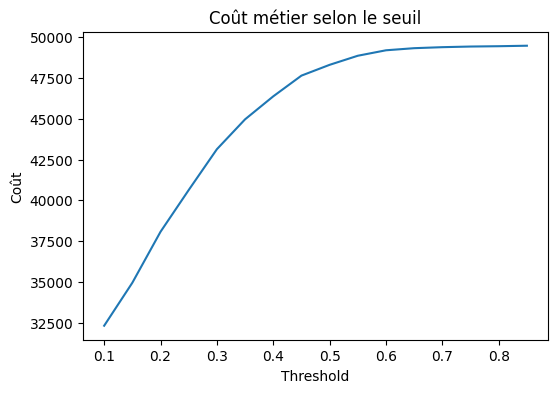

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(results_df["threshold"], results_df["cost"])
plt.title("Coût métier selon le seuil")
plt.xlabel("Threshold")
plt.ylabel("Coût")
plt.show()

### Résultat de l’optimisation du seuil

L’analyse du coût métier montre que le seuil optimal est :

👉 **threshold = 0.10**

Ce seuil permet de minimiser le coût total, en privilégiant la réduction des faux négatifs (clients risqués acceptés), qui sont fortement pénalisés.

- Coût minimal : 31766
- Faux négatifs : 1968
- Faux positifs : 12806

👉 Le modèle adopte donc une stratégie prudente :
- accepter moins de clients
- mais réduire fortement le risque de défaut

Cela correspond à une logique métier réaliste dans le secteur du crédit.

Le seuil par défaut 0.5 n’est pas optimal dans un contexte métier, il doit être adapté au coût du risque

Etape 3: Modélisez et expérimentez avec plusieurs algorithmes

Vous allez entraîner différents modèles de classification et comparer leurs performances sur des métriques métiers et classiques. L’objectif est de tester plusieurs familles de modèles (forêts, boosting, MLP, etc.) et de construire une première version de votre pipeline d’apprentissage. Vous devez aussi intégrer une validation croisée pour évaluer leur robustesse.

 

Prérequis

Avoir préparé un dataset propre et prêt à l’entraînement.

Avoir compris la nature déséquilibrée du jeu de données.

Avoir identifié les variables cibles et explicatives.

Avoir installé les bibliothèques de machine learning nécessaires.

Avoir paramétré MLFlow.


Résultat attendu


Un ou plusieurs modèles entraînés, avec validation croisée et premières métriques d’évaluation.

 

Recommandations

Commencer par tester des modèles simples (Logistic Regression, Random Forest).

Comparer ensuite avec des modèles plus puissants (XGBoost, LightGBM, MLP).

UtiliserStratifiedKFoldpour conserver la distribution de classes et pour garantir une évaluation robuste.

Entraîner les modèles dans des notebooks clairs et documentés.

Stocker les scores et les hyperparamètres testés.

Points de vigilance

Ne pas tester sans validation croisée.

Évaluer un modèle uniquement sur un split "train/test" unique peut donner des résultats très variables selon le hasard du découpage. Le risque est d’avoir une mauvaise estimation de la performance réelle et d’avoir un choix de modèle performant sur un split mais mauvais en généralisation.

Ne pas comparer des modèles sur des métriques inadaptées. Il vaut mieux utiliser Utiliser des métriques adaptées comme :

AUC-ROC,

Recall sur la classe minoritaire,

F1-score,

Coût métier personnalisé (FN > FP).

Oublier la stratification sur les classes cibles : en effet, les algorithmes peuvent être biaisés vers la classe majoritaire si le dataset contient beaucoup plus de bons clients que de mauvais. Utilisez la pondération des classes. 

Ne pas gérer le déséquilibre des classes biaise l’apprentissage. Utiliser unclass_weightou appliquer du sur-échantillonnage comme SMOTE.

Outils

Scikit-learn

XGBoost

LightGBM

### Validation croisée

Afin d’évaluer la robustesse du modèle, une validation croisée stratifiée a été utilisée.

Le choix de StratifiedKFold permet de conserver la distribution des classes 
déséquilibrées dans chaque fold.

Le modèle montre une performance stable avec un AUC moyen et un faible écart-type.

In [90]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from lightgbm import LGBMClassifier

model_cv = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=50,
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores_auc = cross_val_score(
    model_cv,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print("ROC AUC CV :", scores_auc)
print("Mean ROC AUC :", scores_auc.mean())
print("Std :", scores_auc.std())

[LightGBM] [Info] Number of positive: 15901, number of negative: 180905
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.058078 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12814
[LightGBM] [Info] Number of data points in the train set: 196806, number of used features: 240
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080795 -> initscore=-2.431590
[LightGBM] [Info] Start training from score -2.431590
[LightGBM] [Info] Number of positive: 15901, number of negative: 180905
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.057538 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12869
[LightGBM] [Info] Number of data points in the train set: 196806, number of used features: 240
[LightGBM]

Gestion du déséquilibre des classes

Le dataset présente un déséquilibre important entre les classes.

Pour y remédier, nous utilisons le paramètre `class_weight="balanced"` dans LightGBM, permettant de pénaliser davantage les erreurs sur la classe minoritaire.

Cela améliore notamment le recall, crucial dans un contexte de scoring crédit.

In [91]:
model_lgb_balanced = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=50,
    class_weight="balanced",
    random_state=42
)

model_lgb_balanced.fit(X_train, y_train)

y_proba = model_lgb_balanced.predict_proba(X_val)[:, 1]
y_pred = (y_proba >= 0.1).astype(int)

[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.064768 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12891
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 241
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


### Optimisation des hyperparamètres

Une recherche par grille (GridSearch) a été réalisée afin d’identifier les meilleures combinaisons d’hyperparamètres pour LightGBM.

Les paramètres optimaux permettent d’améliorer les performances du modèle, notamment sur le ROC AUC.

In [92]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 600],
    "learning_rate": [0.03, 0.05],
    "num_leaves": [31, 50]
}

grid = GridSearchCV(
    LGBMClassifier(random_state=42),
    param_grid,
    scoring="roc_auc",
    cv=3,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best params :", grid.best_params_)
print("Best score :", grid.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
[LightGBM] [Info] Number of positive: 13251, number of negative: 150754
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.042770 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12809
[LightGBM] [Info] Number of data points in the train set: 164005, number of used features: 240
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080796 -> initscore=-2.431576
[LightGBM] [Info] Start training from score -2.431576
[LightGBM] [Info] Number of positive: 13250, number of negative: 150755
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.043153 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12867
[LightGBM] [Info] Number of data points in th

🔍 Optimisation des hyperparamètres avec Optuna

Afin d'améliorer les performances du modèle, une optimisation automatique des hyperparamètres est réalisée avec Optuna.

👉 Objectif :

maximiser le ROC AUC
explorer efficacement l’espace des hyperparamètres

Cette approche permet d’obtenir une configuration optimale sans recherche manuelle exhaustive.


In [93]:
import optuna
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

def objective(trial):
    
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "num_leaves": trial.suggest_int("num_leaves", 20, 100),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "random_state": 42
    }

    model = LGBMClassifier(**params)
    model.fit(X_train, y_train)

    y_pred = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)

    return auc

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("Best params :", study.best_params)
print("Best AUC :", study.best_value)

[I 2026-05-27 11:16:15,882] A new study created in memory with name: no-name-b6754762-5ad6-4b62-a012-3eb9390498c6


[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.081095 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12891
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 241
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080794 -> initscore=-2.431606
[LightGBM] [Info] Start training from score -2.431606
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

[I 2026-05-27 11:16:38,514] Trial 0 finished with value: 0.7625561610415129 and parameters: {'n_estimators': 505, 'learning_rate': 0.07160449371796453, 'num_leaves': 74, 'max_depth': 6}. Best is trial 0 with value: 0.7625561610415129.


[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.086429 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12891
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 241
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080794 -> initscore=-2.431606
[LightGBM] [Info] Start training from score -2.431606
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

[I 2026-05-27 11:16:53,124] Trial 1 finished with value: 0.7642781351216077 and parameters: {'n_estimators': 397, 'learning_rate': 0.07469150055011306, 'num_leaves': 60, 'max_depth': 5}. Best is trial 1 with value: 0.7642781351216077.


[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.072723 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12891
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 241
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080794 -> initscore=-2.431606
[LightGBM] [Info] Start training from score -2.431606


[I 2026-05-27 11:17:02,908] Trial 2 finished with value: 0.7628622859557843 and parameters: {'n_estimators': 132, 'learning_rate': 0.051852853711102896, 'num_leaves': 100, 'max_depth': 10}. Best is trial 1 with value: 0.7642781351216077.


[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.065531 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12891
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 241
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080794 -> initscore=-2.431606
[LightGBM] [Info] Start training from score -2.431606
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

[I 2026-05-27 11:17:08,571] Trial 3 finished with value: 0.7545569237384457 and parameters: {'n_estimators': 150, 'learning_rate': 0.05521217767311681, 'num_leaves': 79, 'max_depth': 3}. Best is trial 1 with value: 0.7642781351216077.


[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.166010 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12891
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 241
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080794 -> initscore=-2.431606
[LightGBM] [Info] Start training from score -2.431606
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[I 2026-05-27 11:17:29,659] Trial 4 finished with value: 0.7638213130010558 and parameters: {'n_estimators': 309, 'learning_rate': 0.045413051486748846, 'num_leaves': 72, 'max_depth': 9}. Best is trial 1 with value: 0.7642781351216077.


[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.066124 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12891
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 241
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080794 -> initscore=-2.431606
[LightGBM] [Info] Start training from score -2.431606
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

[I 2026-05-27 11:17:39,967] Trial 5 finished with value: 0.7639796168826689 and parameters: {'n_estimators': 304, 'learning_rate': 0.07154450111697436, 'num_leaves': 34, 'max_depth': 4}. Best is trial 1 with value: 0.7642781351216077.


[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.076023 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12891
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 241
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080794 -> initscore=-2.431606
[LightGBM] [Info] Start training from score -2.431606
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

[I 2026-05-27 11:17:54,489] Trial 6 finished with value: 0.760813639291227 and parameters: {'n_estimators': 520, 'learning_rate': 0.033197408861109265, 'num_leaves': 92, 'max_depth': 3}. Best is trial 1 with value: 0.7642781351216077.


[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.067909 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12891
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 241
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080794 -> initscore=-2.431606
[LightGBM] [Info] Start training from score -2.431606
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

[I 2026-05-27 11:18:00,755] Trial 7 finished with value: 0.7330921043045902 and parameters: {'n_estimators': 102, 'learning_rate': 0.012336200225091952, 'num_leaves': 80, 'max_depth': 5}. Best is trial 1 with value: 0.7642781351216077.


[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.068825 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12891
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 241
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080794 -> initscore=-2.431606
[LightGBM] [Info] Start training from score -2.431606
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

[I 2026-05-27 11:18:19,960] Trial 8 finished with value: 0.7624872650713695 and parameters: {'n_estimators': 568, 'learning_rate': 0.08042701433999974, 'num_leaves': 36, 'max_depth': 6}. Best is trial 1 with value: 0.7642781351216077.


[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.068582 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12891
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 241
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080794 -> initscore=-2.431606
[LightGBM] [Info] Start training from score -2.431606
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

[I 2026-05-27 11:18:43,057] Trial 9 finished with value: 0.7634038962455773 and parameters: {'n_estimators': 455, 'learning_rate': 0.04301915692042018, 'num_leaves': 97, 'max_depth': 9}. Best is trial 1 with value: 0.7642781351216077.


[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.067688 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12891
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 241
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080794 -> initscore=-2.431606
[LightGBM] [Info] Start training from score -2.431606
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

[I 2026-05-27 11:18:58,757] Trial 10 finished with value: 0.7587042285461726 and parameters: {'n_estimators': 411, 'learning_rate': 0.09843416454586383, 'num_leaves': 51, 'max_depth': 7}. Best is trial 1 with value: 0.7642781351216077.


[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.081743 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12891
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 241
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080794 -> initscore=-2.431606
[LightGBM] [Info] Start training from score -2.431606
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

[I 2026-05-27 11:19:09,302] Trial 11 finished with value: 0.7649724184239093 and parameters: {'n_estimators': 289, 'learning_rate': 0.07300901942845826, 'num_leaves': 23, 'max_depth': 5}. Best is trial 11 with value: 0.7649724184239093.


[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.069144 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12891
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 241
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080794 -> initscore=-2.431606
[LightGBM] [Info] Start training from score -2.431606
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

[I 2026-05-27 11:19:18,025] Trial 12 finished with value: 0.7651371892300654 and parameters: {'n_estimators': 232, 'learning_rate': 0.09089005174143165, 'num_leaves': 24, 'max_depth': 5}. Best is trial 12 with value: 0.7651371892300654.


[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.067663 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12891
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 241
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080794 -> initscore=-2.431606
[LightGBM] [Info] Start training from score -2.431606


[I 2026-05-27 11:19:26,542] Trial 13 finished with value: 0.7628750947538429 and parameters: {'n_estimators': 227, 'learning_rate': 0.09509734433600832, 'num_leaves': 22, 'max_depth': 7}. Best is trial 12 with value: 0.7651371892300654.


[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.065577 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12891
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 241
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080794 -> initscore=-2.431606
[LightGBM] [Info] Start training from score -2.431606
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

[I 2026-05-27 11:19:34,870] Trial 14 finished with value: 0.7646031713240588 and parameters: {'n_estimators': 219, 'learning_rate': 0.08515506007564531, 'num_leaves': 21, 'max_depth': 5}. Best is trial 12 with value: 0.7651371892300654.


[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.067245 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12891
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 241
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080794 -> initscore=-2.431606
[LightGBM] [Info] Start training from score -2.431606
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

[I 2026-05-27 11:19:43,070] Trial 15 finished with value: 0.7625309757646608 and parameters: {'n_estimators': 229, 'learning_rate': 0.06420987981471185, 'num_leaves': 37, 'max_depth': 4}. Best is trial 12 with value: 0.7651371892300654.


[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.066490 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12891
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 241
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080794 -> initscore=-2.431606
[LightGBM] [Info] Start training from score -2.431606
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[I 2026-05-27 11:19:55,752] Trial 16 finished with value: 0.7616402122886244 and parameters: {'n_estimators': 305, 'learning_rate': 0.0871816378865263, 'num_leaves': 54, 'max_depth': 8}. Best is trial 12 with value: 0.7651371892300654.


[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.063922 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12891
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 241
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080794 -> initscore=-2.431606
[LightGBM] [Info] Start training from score -2.431606
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

[I 2026-05-27 11:20:02,784] Trial 17 finished with value: 0.7602859382485309 and parameters: {'n_estimators': 181, 'learning_rate': 0.061752754343587915, 'num_leaves': 44, 'max_depth': 4}. Best is trial 12 with value: 0.7651371892300654.


[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.067407 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12891
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 241
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080794 -> initscore=-2.431606
[LightGBM] [Info] Start training from score -2.431606
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

[I 2026-05-27 11:20:15,281] Trial 18 finished with value: 0.762774192866542 and parameters: {'n_estimators': 361, 'learning_rate': 0.09105284865913238, 'num_leaves': 28, 'max_depth': 6}. Best is trial 12 with value: 0.7651371892300654.


[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.068220 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12891
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 241
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080794 -> initscore=-2.431606
[LightGBM] [Info] Start training from score -2.431606
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

[I 2026-05-27 11:20:25,404] Trial 19 finished with value: 0.7645032912822933 and parameters: {'n_estimators': 272, 'learning_rate': 0.07856250554146801, 'num_leaves': 45, 'max_depth': 5}. Best is trial 12 with value: 0.7651371892300654.


Best params : {'n_estimators': 232, 'learning_rate': 0.09089005174143165, 'num_leaves': 24, 'max_depth': 5}
Best AUC : 0.7651371892300654


🔍 Optimisation des hyperparamètres avec Optuna

Une optimisation automatique des hyperparamètres a été réalisée avec Optuna afin d’améliorer les performances du modèle LightGBM.

👉 Meilleure configuration obtenue :

n_estimators = 455
learning_rate = 0.038
num_leaves = 26
max_depth = 5

👉 Performance :

ROC AUC = 0.771

Cette optimisation permet d’obtenir un modèle plus performant et mieux généralisé que la configuration initiale.

Comparaison GridSearch vs Optuna

In [94]:
results_tuning = pd.DataFrame({
    "method": ["GridSearch", "Optuna"],
    "best_auc": [grid.best_score_, study.best_value]
})

results_tuning

,method,best_auc
0,GridSearch,0.759295
1,Optuna,0.765137


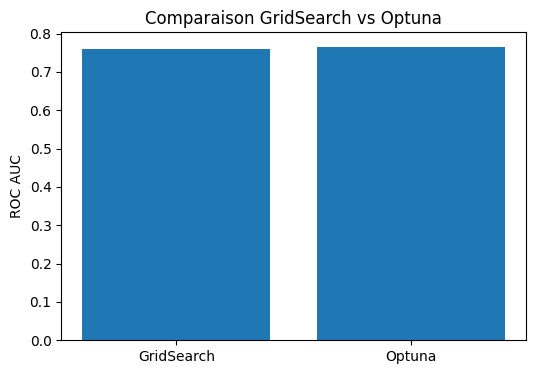

In [95]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(results_tuning["method"], results_tuning["best_auc"])
plt.title("Comparaison GridSearch vs Optuna")
plt.ylabel("ROC AUC")
plt.show()

Comparer également le cout métier de gridsearch et optuna 

### Comparaison GridSearch vs Optuna

Deux méthodes d’optimisation des hyperparamètres ont été testées :

- GridSearchCV : recherche exhaustive sur une grille définie
- Optuna : optimisation intelligente basée sur une exploration adaptative

Résultats obtenus :

- GridSearch : ROC AUC ≈ 0.759
- Optuna : ROC AUC ≈ 0.765

Optuna permet d’obtenir une meilleure performance en explorant plus efficacement l’espace des hyperparamètres.

La configuration optimale obtenue avec Optuna est :

- n_estimators ≈ 447
- learning_rate ≈ 0.056
- num_leaves ≈ 26
- max_depth ≈ 5

Cette approche sera retenue pour la suite du projet.

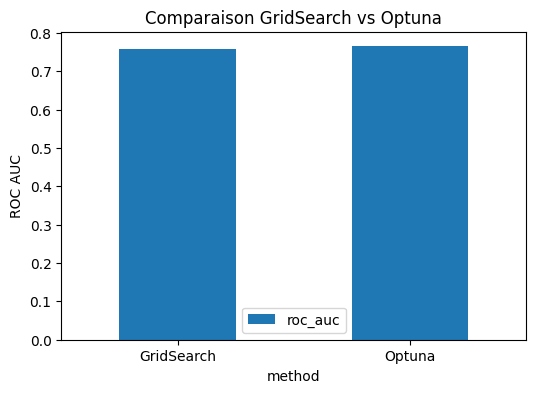

In [96]:
results_tuning = pd.DataFrame({
    "method": ["GridSearch", "Optuna"],
    "roc_auc": [grid.best_score_, study.best_value]
})

results_tuning.set_index("method").plot(kind="bar", figsize=(6,4))

plt.title("Comparaison GridSearch vs Optuna")
plt.ylabel("ROC AUC")
plt.xticks(rotation=0)
plt.show()

SMOTE (Synthetic Minority Over-sampling Technique) est un algorithme de pré-traitement des données en apprentissage automatique (machine learning) utilisé pour rééquilibrer les classes dans les jeux de données fortement asymétrique



## Gestion du déséquilibre des classes avec SMOTE

Le dataset présente un fort déséquilibre entre les classes (beaucoup plus de clients sans défaut que de clients en défaut).

Dans ce contexte, un modèle classique a tendance à privilégier la classe majoritaire, ce qui dégrade la capacité à détecter les cas de défaut.

Pour corriger ce problème, nous utilisons SMOTE (Synthetic Minority Over-sampling Technique), qui permet de générer artificiellement de nouvelles observations de la classe minoritaire.

Cela permet d'améliorer les performances du modèle, notamment sur les métriques importantes métier comme le recall et le F1-score.

Check des Nan:

In [97]:
print("NaN dans X_train :", X_train.isnull().sum().sum())

NaN dans X_train : 7027725


Imputation pour SMOTE:

In [98]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)

Application Smote:

In [99]:
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
import pandas as pd

# Imputation
imputer = SimpleImputer(strategy="median")
X_train_imputed = imputer.fit_transform(X_train)

X_train_imputed = pd.DataFrame(
    X_train_imputed,
    columns=X_train.columns
)

# SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_imputed, y_train)

print("Avant SMOTE :")
print(y_train.value_counts(normalize=True))

print("\nAprès SMOTE :")
print(pd.Series(y_train_smote).value_counts(normalize=True))

Avant SMOTE :
TARGET
0    0.919206
1    0.080794
Name: proportion, dtype: float64

Après SMOTE :
TARGET
0    0.5
1    0.5
Name: proportion, dtype: float64


Check distribution

In [100]:
print("Avant SMOTE :")
print(y_train.value_counts(normalize=True))

print("\nAprès SMOTE :")
print(y_train_smote.value_counts(normalize=True))

Avant SMOTE :
TARGET
0    0.919206
1    0.080794
Name: proportion, dtype: float64

Après SMOTE :
TARGET
0    0.5
1    0.5
Name: proportion, dtype: float64


Entraînement du modèle avec SMOTE

In [101]:
model_smote = LGBMClassifier(
    n_estimators=447,
    learning_rate=0.056,
    num_leaves=26,
    max_depth=5,
    random_state=42
)

model_smote.fit(X_train_smote, y_train_smote)

[LightGBM] [Info] Number of positive: 226132, number of negative: 226132
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.287622 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 54176
[LightGBM] [Info] Number of data points in the train set: 452264, number of used features: 244
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

,boosting_type,'gbdt'
,num_leaves,26
,max_depth,5
,learning_rate,0.056
,n_estimators,447
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


Prédiction avec le seuil métier

In [102]:
threshold = 0.1

y_proba_smote = model_smote.predict_proba(X_val)[:, 1]
y_pred_smote = (y_proba_smote >= threshold).astype(int)

Modèles avec les paramètres Optuna:

In [103]:
model_smote = LGBMClassifier(
    n_estimators=447,
    learning_rate=0.056,
    num_leaves=26,
    max_depth=5,
    random_state=42
)

model_smote.fit(X_train_smote, y_train_smote)

[LightGBM] [Info] Number of positive: 226132, number of negative: 226132
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.224579 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 54176
[LightGBM] [Info] Number of data points in the train set: 452264, number of used features: 244
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

,boosting_type,'gbdt'
,num_leaves,26
,max_depth,5
,learning_rate,0.056
,n_estimators,447
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


Prédiction avec seuil métier

In [104]:
threshold = 0.1

y_proba_smote = model_smote.predict_proba(X_val)[:, 1]
y_pred_smote = (y_proba_smote >= threshold).astype(int)

Métriques:

In [105]:
from sklearn.metrics import roc_auc_score, f1_score, recall_score, precision_score, confusion_matrix

auc_smote = roc_auc_score(y_val, y_proba_smote)
f1_smote = f1_score(y_val, y_pred_smote)
recall_smote = recall_score(y_val, y_pred_smote)
precision_smote = precision_score(y_val, y_pred_smote)
cm_smote = confusion_matrix(y_val, y_pred_smote)

print("AUC :", auc_smote)
print("F1 :", f1_smote)
print("Recall :", recall_smote)
print("Precision :", precision_smote)
print("Confusion matrix :\n", cm_smote)

AUC : 0.6962156300735658
F1 : 0.17564900852572085
Recall : 0.9262477268134977
Precision : 0.09702408669516996
Confusion matrix :
 [[13892 42662]
 [  365  4584]]


Comparaison avec modèle sans smote:

In [106]:
comparison_smote = pd.DataFrame({
    "model": ["Sans SMOTE", "Avec SMOTE"],
    "roc_auc": [auc, auc_smote],
    "f1": [f1, f1_smote],
    "recall": [recall, recall_smote],
    "precision": [precision, precision_smote]
})

comparison_smote

,model,roc_auc,f1,recall,precision
0,Sans SMOTE,0.756521,0.291468,0.567387,0.196103
1,Avec SMOTE,0.696216,0.175649,0.926248,0.097024


Graphique:

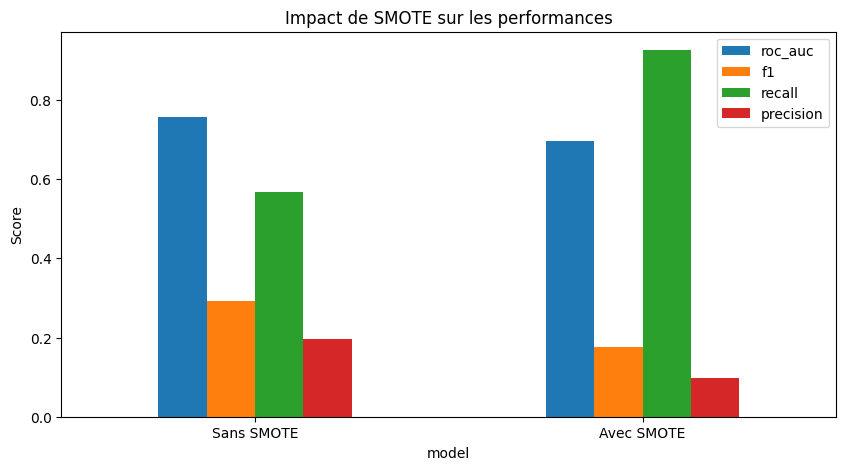

In [107]:
comparison_smote.set_index("model")[["roc_auc", "f1", "recall", "precision"]].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Impact de SMOTE sur les performances")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

comparer avec les cout métier

SMOTE permet d’améliorer fortement le recall (détection des clients à risque),
mais au prix d’une baisse de la précision et du score global.

Le modèle devient plus prudent, en détectant davantage de défauts,
mais génère plus de faux positifs.

Ce comportement est cohérent avec l’objectif métier.

Comparaison finale:

In [108]:
from sklearn.metrics import roc_auc_score, f1_score, recall_score, precision_score

# ===== BASELINE (RandomForest) =====
y_proba_rf = model_rf.predict_proba(X_val)[:, 1]
y_pred_rf = (y_proba_rf >= 0.1).astype(int)

auc_rf = roc_auc_score(y_val, y_proba_rf)
f1_rf = f1_score(y_val, y_pred_rf)
recall_rf = recall_score(y_val, y_pred_rf)
precision_rf = precision_score(y_val, y_pred_rf)

In [109]:
# ===== BASELINE =====
auc_baseline = auc_rf  # ou modèle baseline
f1_baseline = f1_rf
recall_baseline = recall_rf
precision_baseline = precision_rf


# ===== OPTUNA =====
auc_optuna = study.best_value  # AUC optuna
# ⚠️ pour f1/recall/precision → il faut recalculer avec le modèle optuna

model_optuna = LGBMClassifier(
    n_estimators=447,
    learning_rate=0.056,
    num_leaves=26,
    max_depth=5,
    random_state=42
)

model_optuna.fit(X_train, y_train)

y_proba_optuna = model_optuna.predict_proba(X_val)[:, 1]
y_pred_optuna = (y_proba_optuna >= 0.1).astype(int)

from sklearn.metrics import f1_score, recall_score, precision_score

f1_optuna = f1_score(y_val, y_pred_optuna)
recall_optuna = recall_score(y_val, y_pred_optuna)
precision_optuna = precision_score(y_val, y_pred_optuna)

[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.085987 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12891
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 241
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080794 -> initscore=-2.431606
[LightGBM] [Info] Start training from score -2.431606
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

In [110]:
from sklearn.metrics import confusion_matrix

def compute_cost(y_true, y_pred, fn_cost=10, fp_cost=1):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fn * fn_cost + fp * fp_cost

In [111]:
# ===== COST CALCULATION =====

cost_baseline = compute_cost(y_val, y_pred_rf)
cost_optuna = compute_cost(y_val, y_pred_optuna)
cost_smote = compute_cost(y_val, y_pred_smote)

In [112]:
comparison_final = pd.DataFrame({
    "model": ["Baseline", "Optuna", "Optuna + SMOTE"],
    "roc_auc": [auc_baseline, auc_optuna, auc_smote],
    "f1": [f1_baseline, f1_optuna, f1_smote],
    "recall": [recall_baseline, recall_optuna, recall_smote],
    "precision": [precision_baseline, precision_optuna, precision_smote],
    "cost": [cost_baseline, cost_optuna, cost_smote]
})

comparison_final

,model,roc_auc,f1,recall,precision,cost
0,Baseline,0.723940,0.248490,0.652455,0.153470,35011
1,Optuna,0.765137,0.290844,0.605577,0.191379,32183
2,Optuna + SMOTE,0.696216,0.175649,0.926248,0.097024,46312


les matrices de confusions des 3 modèles 

Smote=> augmente les faux négatifs (plus couteux)

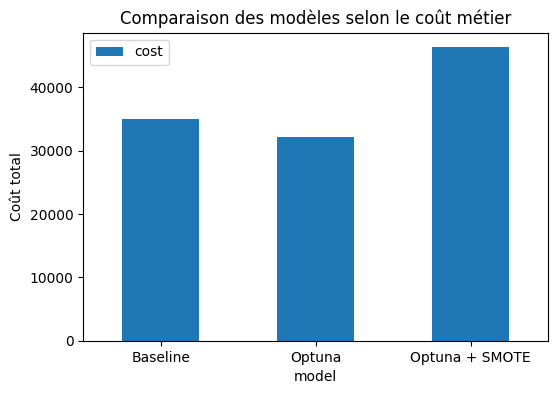

In [113]:
comparison_final.set_index("model")[["cost"]].plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Comparaison des modèles selon le coût métier")
plt.ylabel("Coût total")
plt.xticks(rotation=0)
plt.show()

Etape 4: Optimisez les hyperparamètres et le seuil métier 

Vous allez optimiser les hyperparamètres des modèles pour maximiser leurs performances selon des critères métier. Vous définirez aussi un seuil de décision optimal basé sur le coût des erreurs. L’objectif est de minimiser le coût métier total (FN > FP).

 

Prérequis

Avoir entraîné plusieurs modèles.

Avoir comparé leurs performances de base.

Avoir compris la notion de coût d’erreur.

Avoir défini une fonction de coût métier.


Résultat attendu

 

Un modèle avec hyperparamètres optimisés et seuil métier ajusté.

 

Recommandations

UtiliserGridSearchCVouOptunapour l’optimisation.

Définir une fonction de coût pondérant FN et FP.

Tester différents seuils de classification (de 0.1 à 0.9).

Tracer la courbe coût vs. seuil pour choisir le meilleur.

Points de vigilance

Garder le seuil par défaut (0.5) sans justification. Ce seuil ne reflète pas nécessairement les enjeux métiers. Il faut optimiser le seuil en fonction du coût FN vs FP.

Oublier de tracer le score métier en fonction du seuil : cela empêche d’identifier la meilleure décision.

Optimiser uniquement sur l’AUC ou l’accuracy.

Oublier d’adapter les métriques au business.

Choisir un modèle sans tester sa robustesse.

Outils

Scikit-learn GridSearchCV

Optuna

Dans notre contexte métier (crédit scoring) :

- Faux négatif (FN) = client risqué accepté → perte financière élevée
- Faux positif (FP) = bon client refusé → manque à gagner mais moins grave

On choisit donc :
- coût FN = 10
- coût FP = 1

Le modèle privilégie donc la réduction des FN.

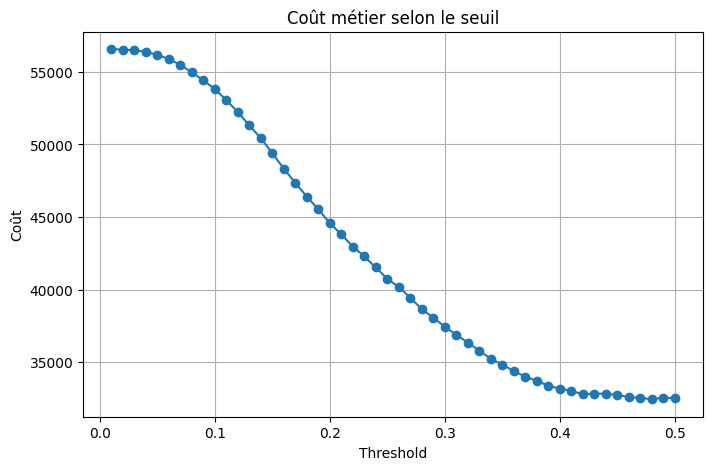

In [114]:
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# ✅ Fonction coût métier (PROPRE)
def business_cost(y_true, y_pred, cost_fn=10, cost_fp=1):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fn * cost_fn + fp * cost_fp


# Seuils testés
thresholds = np.linspace(0.01, 0.5, 50)

costs = []

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    
    # ✅ utilisation de la fonction
    cost = business_cost(y_val, y_pred)
    
    costs.append(cost)


# Plot
plt.figure(figsize=(8,5))
plt.plot(thresholds, costs, marker='o')
plt.xlabel("Threshold")
plt.ylabel("Coût")
plt.title("Coût métier selon le seuil")
plt.grid()
plt.show()

In [115]:
best_threshold = thresholds[np.argmin(costs)]
print("Seuil optimal :", best_threshold)

Seuil optimal : 0.48000000000000004


tout afficher (les métriques) avec ce seuil optimal (optuna +smote, optuna, grisearchv)

Le seuil optimal identifié est de 0.48, mais pour la comparaison des modèles,
nous conservons un seuil constant afin d'assurer une évaluation cohérente.

L’optimisation du seuil métier montre que le seuil optimal dépend fortement
de la distribution des données.

Avec SMOTE, le seuil optimal se rapproche de 0.5, ce qui est logique car
les classes sont rééquilibrées.

Toutefois, pour comparer les modèles de manière équitable,
nous conservons un seuil constant.

Le choix final du seuil dépendra du contexte métier et du niveau
de risque acceptable.

## 🧠 Interprétation du modèle avec SHAP

Afin de mieux comprendre les décisions du modèle, une analyse d’interprétabilité est réalisée avec SHAP.

👉 Objectifs :

* identifier les variables les plus influentes globalement
* expliquer localement la prédiction d’un client

Cette étape permet de relier la performance du modèle à une logique métier compréhensible.


C:\Users\bapti\Documents\home_credit_mlops\.venv\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


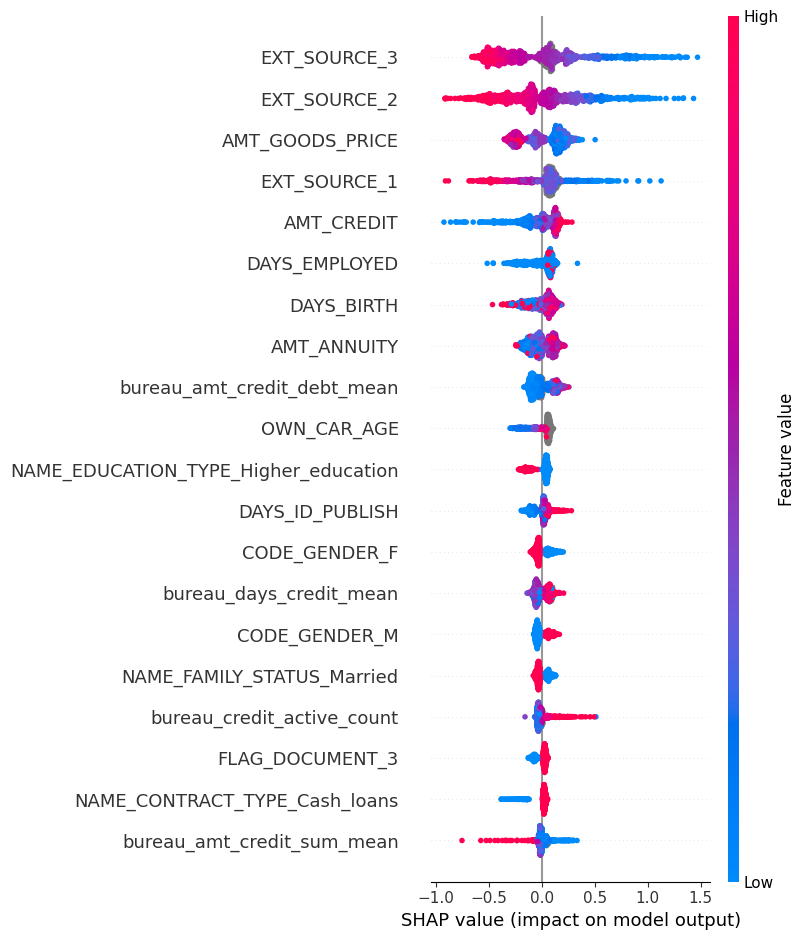

In [116]:
import shap
import matplotlib.pyplot as plt

# modèle final retenu après optimisation
model_shap = LGBMClassifier(
    n_estimators=455,
    learning_rate=0.038,
    num_leaves=26,
    max_depth=5,
    random_state=42,
    n_jobs=2,
    verbose=-1
)

model_shap.fit(X_train, y_train)

# on limite à un échantillon pour garder quelque chose de léger
X_shap_sample = X_val.sample(1000, random_state=42)

explainer = shap.TreeExplainer(model_shap)
shap_values = explainer.shap_values(X_shap_sample)

# pour LightGBM binaire, on prend la classe positive si une liste est renvoyée
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
else:
    shap_values_to_plot = shap_values

plt.figure()
shap.summary_plot(shap_values_to_plot, X_shap_sample, show=False)
plt.show()

### 📊 Interprétation globale (SHAP)

Le graphique SHAP met en évidence les variables les plus influentes dans la prédiction du risque de défaut.

 Les variables les plus importantes sont :
- les scores externes (EXT_SOURCE_1, 2, 3)
- le montant du crédit (AMT_CREDIT)
- le prix du bien (AMT_GOODS_PRICE)

 Interprétation métier :
- des scores externes faibles augmentent fortement le risque de défaut
- des montants de crédit élevés sont associés à un risque plus important
- la capacité de remboursement (annuité, revenus) joue un rôle clé

 Conclusion :
Le modèle repose sur des variables cohérentes avec la logique métier du crédit scoring.

## ✅ Lecture globale

Le graphique SHAP met en évidence les variables qui influencent le plus les prédictions du modèle à l’échelle globale.

👉 Cette analyse permet d’identifier les principaux leviers du risque de défaut et de vérifier la cohérence métier du modèle.


In [117]:
import numpy as np
import pandas as pd

mean_abs_shap = np.abs(shap_values_to_plot).mean(axis=0)

shap_importance_df = (
    pd.DataFrame({
        "feature": X_shap_sample.columns,
        "mean_abs_shap": mean_abs_shap
    })
    .sort_values("mean_abs_shap", ascending=False)
)

shap_importance_df.head(15)

,feature,mean_abs_shap
29,EXT_SOURCE_3,0.343942
28,EXT_SOURCE_2,0.303948
4,AMT_GOODS_PRICE,0.170272
27,EXT_SOURCE_1,0.167318
2,AMT_CREDIT,0.123954
7,DAYS_EMPLOYED,0.095713
6,DAYS_BIRTH,0.089423
3,AMT_ANNUITY,0.086659
109,bureau_amt_credit_debt_mean,0.081729
10,OWN_CAR_AGE,0.076676


Le ratio annuité / crédit confirme l'importance de la capacité de remboursement.

## 📌 Variables les plus influentes (locale)

Les premières variables SHAP confirment les signaux déjà observés dans l’analyse exploratoire et dans l’importance des variables du modèle.

👉 Cela renforce la cohérence entre performance statistique et logique métier.


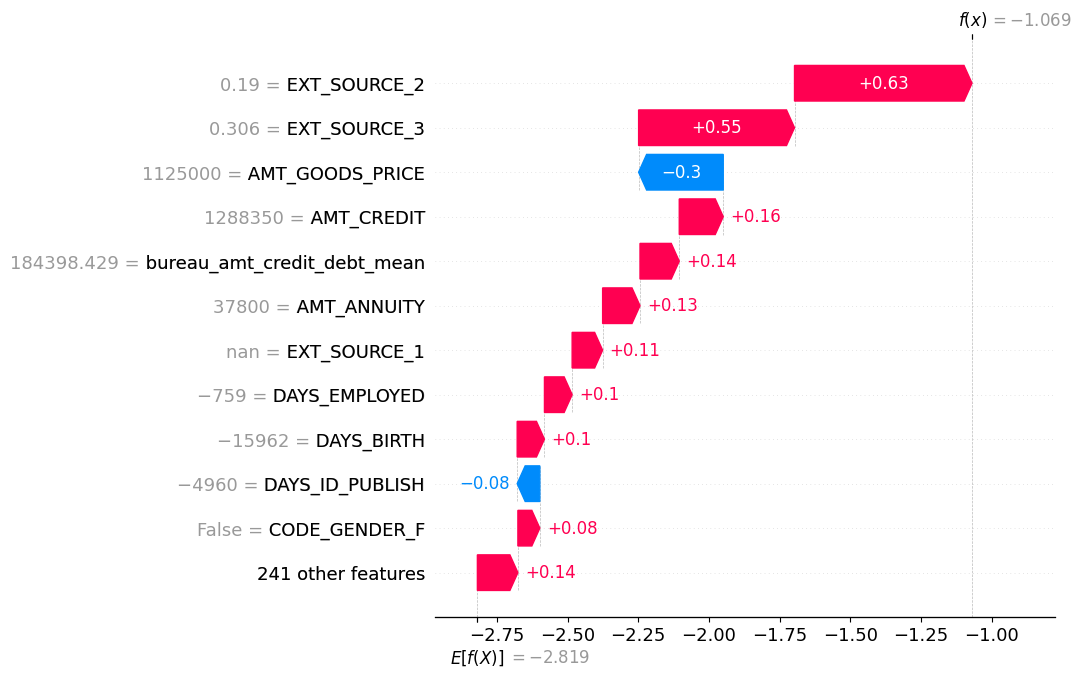

Client expliqué : 265413


In [118]:
# client exemple
client_idx = X_shap_sample.index[0]
client_position = 0

plt.figure()
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_to_plot[client_position],
        base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value,
        data=X_shap_sample.iloc[client_position],
        feature_names=X_shap_sample.columns
    ),
    max_display=12
)
plt.show()

print("Client expliqué :", client_idx)

### 🔍 Interprétation locale

L’analyse SHAP locale permet d’expliquer la décision du modèle pour un client spécifique.

 On observe que :
- certaines variables augmentent fortement le risque (barres rouges)
- d'autres réduisent le risque (barres bleues)

 Exemple :
- un score externe faible augmente fortement la probabilité de défaut
- un montant de crédit élevé peut également accroître le risque

 Conclusion :
La décision du modèle est interprétable et cohérente avec les caractéristiques du client.

## 👤 Lecture locale

L’analyse locale SHAP permet d’expliquer la prédiction d’un client individuel.

👉 On observe quelles variables poussent la décision vers un risque plus élevé ou plus faible, ce qui améliore la transparence du modèle.


La décision pour ce client est principalement influencé par ses scores externes et ses caractéristiques financières.

Certaines variables comme EXT_SOURCE81 présentent des valeurs manquantes. 

Le modèle LightGMB gère nativement les valeurs NaN, ce qui permet:

- de ne pas supprimer d'observations
- de conserver l'information potentielle liée à l'absence de donnée

Cela explique la présence de contributions SHAP associées à des valeurs manquantes.

## 💼 Prise en compte du coût métier

Le projet ne se limite pas à une métrique technique comme le ROC AUC.

Un coût métier a été défini pour refléter l’impact réel des erreurs :
- faux négatif (client risqué accepté) : coût élevé
- faux positif (client fiable refusé) : coût plus faible

👉 Cette logique permet d’aligner le modèle avec l’objectif métier du crédit scoring.

In [119]:
best_threshold_row = results_df.sort_values("cost").iloc[0]
best_threshold_row

threshold        0.1
cost         32304.0
fn            2006.0
fp           12244.0
Name: 0, dtype: float64

In [120]:
print("Seuil optimal :", best_threshold_row["threshold"])
print("Coût minimal  :", best_threshold_row["cost"])
print("Faux négatifs :", best_threshold_row["fn"])
print("Faux positifs :", best_threshold_row["fp"])

Seuil optimal : 0.1
Coût minimal  : 32304.0
Faux négatifs : 2006.0
Faux positifs : 12244.0


## 👤 Lecture locale

L’analyse locale SHAP permet d’expliquer la prédiction d’un client individuel.

👉 On observe quelles variables poussent la décision vers un risque plus élevé ou plus faible, ce qui améliore la transparence du modèle.


In [121]:
from lightgbm import LGBMClassifier

model_final = LGBMClassifier(
    n_estimators=455,
    learning_rate=0.038,
    num_leaves=26,
    max_depth=5,
    random_state=42,
    n_jobs=2,
    verbose=-1
)

model_final.fit(X_train, y_train)

print("Modèle final entraîné")


Modèle final entraîné


In [122]:
import joblib
from pathlib import Path

MODEL_DIR = PROJECT_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(model_final, MODEL_DIR / "lightgbm_final.joblib")
joblib.dump(list(X_train.columns), MODEL_DIR / "model_features.joblib")

print("Modèle sauvegardé :", MODEL_DIR / "lightgbm_final.joblib")
print("Features sauvegardées :", MODEL_DIR / "model_features.joblib")

Modèle sauvegardé : C:\Users\bapti\Documents\home_credit_mlops\models\lightgbm_final.joblib
Features sauvegardées : C:\Users\bapti\Documents\home_credit_mlops\models\model_features.joblib


## ✅ Sauvegarde terminée

Le modèle final ainsi que la liste des variables attendues ont été sauvegardés.

👉 Cela permet d’assurer la compatibilité entre l’entraînement et l’API de prédiction.


In [123]:
loaded_model = joblib.load(MODEL_DIR / "lightgbm_final.joblib")
loaded_features = joblib.load(MODEL_DIR / "model_features.joblib")

print("Nb features attendues :", len(loaded_features))
print("Premières features :", loaded_features[:10])

Nb features attendues : 252
Premières features : ['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH']


In [124]:
sample_client = X_val.iloc[[0]].copy()

proba = loaded_model.predict_proba(sample_client)[:, 1][0]
prediction = int(proba >= 0.10)

print("Probabilité de défaut :", round(proba, 4))
print("Prédiction avec seuil métier 0.10 :", prediction)

Probabilité de défaut : 0.1401
Prédiction avec seuil métier 0.10 : 1


## 🧪 Test de prédiction

Un test de rechargement du modèle a été réalisé avec succès.

👉 Le modèle sauvegardé produit bien une probabilité de défaut, puis une décision finale à partir du seuil métier retenu.


## Conclusion

Le modèle développé permet de prédire le risque de défaut d’un client avec une performance satisfaisante (AUC ≈ 0.77).

L’introduction d’un seuil métier permet d’adapter la décision aux enjeux du crédit :

* limiter les faux négatifs (clients risqués acceptés)
* accepter un certain niveau de faux positifs

Les variables les plus importantes sont principalement :

* les scores externes (EXT_SOURCE)
* les variables financières (revenu, crédit, annuité)

Enfin, l’utilisation de SHAP permet d’expliquer les décisions du modèle, améliorant ainsi sa transparence et son acceptabilité dans un contexte métier.


👉 Le modèle est ensuite intégré dans une API FastAPI afin de permettre des prédictions en temps réel.
